# Project 2 : Supervised Learning
## Thom CHHUN
## Ali DABALE ALI
### GROUP DIA2 A4

### Teacher :  Kezhan Shi (shikezhan@gmail.com)

### Veuillez trouver notre application Streamlit :

### Contexte :
- Des enquêtes de satisfaction ont été réalisées auprès des clients d'assurance. L'étude se concentre sur l'analyse des commentaires libres issus de ces enquêtes, scrappés sur le web.
- Les avis sont en français puis traduits en anglais pour le NLP

### Objectifs :
- Identifier les thématiques abordées dans les commentaires clients
- Comprendre l'impact de ces thématiques sur le niveau de satisfaction
- apprentissage supervisé, apprentissage non supervisé, machine learning, deep learning

### Techniques utilisées :
- Réaliser une analyse exploratoire des données (distribution des notes, des assureurs, des produits)
- Identifier les thématiques par méthodes NLP (topic detection, sentiment analysis, prédiction de produit et de note)

### Problématique :
- Comment le Natural Language Proccessing (NLP) permet de comprendre la valeur des mots pour décrire une note, un produit ou une assurance ?
- Les mots d'un avis client suffisent-ils à prédire une note, un produit ou une assurance ?

### Librairies

In [1]:
# Text processing
import re
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Data manipulation and math
import pandas as pd
import numpy as np
from collections import Counter
import os
import pickle
import struct
import warnings

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.cm as cm

# Machine Learning / NLP
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Advanced models and embeddings
import gensim.downloader
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
import xgboost as xgb
from xgboost import XGBClassifier

# Optional / external APIs
import ollama
import tensorflow_hub as hub
from textblob import TextBlob

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Thom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Thom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Thom\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 1) Chargement des données

On a utilisé le jeu de données : https://drive.google.com/file/d/1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip/view?usp=sharing

You will undertake an initial exploration of the data, including data cleaning, visualization, and
the production of initial conclusions. This step is crucial to establish a solid foundation for
subsequent projects.

In [30]:
dfs = []
for i in range(1, 36):
    file = f"data/Traduction avis clients/avis_{i}_traduit.xlsx"
    df = pd.read_excel(file)
    dfs.append(df)
reviews = pd.concat(dfs, ignore_index=True)

reviews = reviews.dropna(subset=["auteur", "avis", "assureur", "produit", "type", "date_publication", "date_exp", "avis_en"])
reviews = reviews.drop(columns=["avis_cor", "avis_cor_en"])
reviews["date_publication"] = pd.to_datetime(reviews["date_publication"], dayfirst=True)
reviews["date_exp"] = pd.to_datetime(reviews["date_exp"], dayfirst=True)
reviews = reviews[reviews["avis_en"] != "Loading..."]

reviews.to_excel("data/reviews.xlsx", index=False)

## 2) Nettoyage des données

Summary, Translation, and Generation: Produce a clean file with multiple cleaned columns and corrected/translated
texts

### Variables :
- Contextes de la publication des avis (auteur, date de publication)
- Contexte du produit d’assurance (type de produit, assureur)
- Avis client
- Traduction de l’avis en anglais
- Note associée

### Traduction et Correction orthographique

### Suppression des dates, des avis avec textes absents, des annomalies (« Loading... »), probablement un problème lors du scraping

### Traitement des mots avec accents

### Nettoyage différent par type de prédiction :
- Analyse des Sentiments
- Prédiction des Notes
- Détection des Catégories/Sujets
- Recommandation d’Assureurs
- Prédiction des Produits

### Méthodes utilisées :
- Spacy
- Lemmatization
- Lowercase
- Undersampling
- Stopwords

### Export des fichiers nettoyés

In [31]:
df=pd.read_excel("data/reviews.xlsx")
counts = df['note'].value_counts().sort_index()
print(counts)

note
1.0    7101
2.0    3637
3.0    3293
4.0    4771
5.0    4745
Name: count, dtype: int64


### Correction d'orthographe

In [32]:
def correct_spelling(text):
    if pd.isna(text):
        return text
    return str(TextBlob(text).correct())

df["avis_en"] = df["avis_en"].apply(correct_spelling)

### Nettoyage différent par type de prédiction

Nous avons fait un nettoyage différent pour chaque méthode de NLP. En effet, selon la tâche, tous les mots n’ont pas la même importance. Pour le star prediction et le sentiment analysis, les mots qui expriment la négation comme no, not ou n't sont très importants, car ils peuvent complètement changer le sens d’une phrase. De même, les adjectifs d’intensité comme very, extremely ou poorly permettent de faire la différence entre une note élevée (4 ou 5 étoiles par exemple). C’est pour cela que nous avons choisi de ne pas supprimer ces mots, et d’éviter une lemmatisation trop agressive dans ces cas-là.

En revanche, pour des tâches comme le topic detection ou le product prediction, l’objectif est plutôt de comprendre le thème global du texte. Dans ce cas, supprimer les mots inutiles et simplifier les mots grâce à la lemmatisation peut aider le modèle à mieux se concentrer sur les informations importantes. C’est pourquoi nous avons utilisé SpaCy pour obtenir un texte plus propre et plus standardisé dans ces situations.

Ensuite, nous avons préparé les données pour l’apprentissage en nettoyant les valeurs manquantes, en transformant les notes en labels utilisables par les modèles, et en sélectionnant uniquement les données d’entraînement. Nous avons aussi généré plusieurs versions du dataset nettoyé afin de pouvoir tester différentes approches et comparer les résultats.

Enfin, nous avons appliqué du undersampling. En effet, toutes les classes ne sont pas représentées de la même manière dans le dataset, notamment pour les étoiles. Certaines notes sont beaucoup plus fréquentes que d’autres, ce qui peut biaiser les modèles. Pour éviter cela, nous avons limité le nombre d’exemples par classe afin d’avoir des données plus équilibrées. Nous avons même testé plusieurs stratégies d’équilibrage pour voir leur impact sur les performances des modèles.

In [33]:
#!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
from spacy.lang.en.stop_words import STOP_WORDS

stop_words = STOP_WORDS

def clean_text_spacy(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Zéèàùçâêîôû ]', ' ', text)
    # SpaCy pipeline
    doc = nlp(text)
    tokens = []
    for token in doc:
        # Keep only:
        # - alphabetic words
        # - not stopwords
        # - not punctuation
        if (
            token.is_alpha
            and not token.is_stop
            and token.text not in stop_words
        ):
            # Lemmatization
            tokens.append(token.lemma_)
    return " ".join(tokens)

In [34]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = text.replace("n't", " not")
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove weird characters but keep apostrophes
    text = re.sub(r"[^a-zA-Z' ]", " ", text)
    return text

In [35]:
stop_words = set(stopwords.words('english'))
negations = {"no", "not", "never", "nor", "n't"}
intensifiers = {"very", "extremely", "really", "so", "too", "super"}
stop_words = stop_words - negations - intensifiers

lemmatizer = WordNetLemmatizer()

def clean_textV2(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = text.replace("n't", " not")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z' ]", " ", text)
    words = word_tokenize(text)
    words = [
        lemmatizer.lemmatize(w, pos='v') if w not in intensifiers else w
        for w in words
        if w not in stop_words
    ]
    return " ".join(words)

### Nettoyage avec Spacy

In [36]:
df_test=df.copy()
df["avis_spacy"] = df["avis_en"].apply(clean_text_spacy)
#df = df[df["type"] == "train"].reset_index(drop=True)
df.to_excel("data/reviews_clean.xlsx", index=False)

### Nettoyage avec Undersampling

In [37]:
df = df_test.copy()
df["avis_cor"] = df["avis_en"].apply(clean_text)
df = df[["note", "auteur", "avis", "avis_en", "assureur", "produit", "type", "date_publication", "date_exp", "avis_cor"]]

df = df.dropna(subset=["avis_cor", "note"])
df["avis_cor"] = df["avis_cor"].astype(str).str.strip()
df["note"] = pd.to_numeric(df["note"], errors="coerce")
df = df.dropna(subset=["note"])
df["note"] = df["note"].astype(int)
df["label"] = df["note"] - 1
df["type"] = df["type"].astype(str).str.lower().str.strip()

labeled_df = df[df["type"] == "train"].reset_index(drop=True)
N_PER_CLASS = 3000
labeled_df = (labeled_df.groupby("label", group_keys=False)
                         .apply(lambda x: x.sample(min(N_PER_CLASS, len(x)), random_state=42))
                         .reset_index(drop=True))

print(f"After undersampling ({N_PER_CLASS}/class):")
print(labeled_df["note"].value_counts().sort_index())

labeled_df.to_excel("data/reviews_nlp.xlsx", index=False)

After undersampling (3000/class):
note
1    3000
2    3000
3    3000
4    3000
5    3000
Name: count, dtype: int64


### Nettoyage pour Analyse de Sentiments

In [39]:
df = df_test.copy()
df["avis_cor"] = df["avis_en"].apply(clean_text)

df = df[["note", "auteur", "avis", "avis_en", "assureur", "produit", "type", "date_publication", "date_exp", "avis_cor"]]

df = df.dropna(subset=["avis_cor", "note"])
df["avis_cor"] = df["avis_cor"].astype(str).str.strip()
df["note"] = pd.to_numeric(df["note"], errors="coerce")
df = df.dropna(subset=["note"])
df["note"] = df["note"].astype(int)
df["label"] = df["note"] - 1  # 0..4
df["type"] = df["type"].astype(str).str.lower().str.strip()

quota_dict = {1: 3000, 2: 0, 3: 3000, 4: 0, 5: 3000}

labeled_df = df[df["type"] == "train"].reset_index(drop=True)
labeled_df = (
    labeled_df.groupby("note", group_keys=False)
              .apply(lambda x: x.sample(min(quota_dict[x.name], len(x)),
                                         random_state=42))
              .reset_index(drop=True)
)

#print("Counts after targeted undersampling :")
#print(labeled_df["note"].value_counts().sort_index())
labeled_df.to_excel("data/reviews_sen.xlsx", index=False)

### Nettoyage pour Topic Detection

In [40]:
df = df_test.copy()
df["avis_cor"] = df["avis_en"].apply(clean_text)

df = df[["note", "auteur", "avis", "avis_en", "assureur", "produit", "type", "date_publication", "date_exp", "avis_cor"]]

df = df.dropna(subset=["avis_cor", "note"])
df["avis_cor"] = df["avis_cor"].astype(str).str.strip()
df["note"] = pd.to_numeric(df["note"], errors="coerce")
df = df.dropna(subset=["note"])
df["note"] = df["note"].astype(int)
df["label"] = df["note"] - 1  # 0..4
df["type"] = df["type"].astype(str).str.lower().str.strip()

quota_dict = {1: 500, 2: 500, 3: 500, 4: 500, 5: 500}

labeled_df = df[df["type"] == "train"].reset_index(drop=True)
labeled_df = (
    labeled_df.groupby("note", group_keys=False)
              .apply(lambda x: x.sample(min(quota_dict[x.name], len(x)),
                                         random_state=42))
              .reset_index(drop=True)
)

labeled_df.to_excel("data/reviews_sub.xlsx", index=False)

## 3) N-grams

#### Mise en évidence des mots (et n-grammes) fréquents

Dans cette partie, nous avons cherché à mieux comprendre le contenu des avis clients en analysant les mots les plus fréquents. Pour cela, nous avons utilisé une approche basée sur les n-grams, ici principalement des mots seuls (unigrams), afin d’identifier les termes qui reviennent le plus souvent dans les textes nettoyés.

Grâce à ces visualisations, on peut voir que les mots les plus représentés sont year, month, contract et time. Cela montre que pour les clients, la notion de temps est très importante, et qu’ils n’aiment pas attendre ou subir des délais trop longs. De plus, les mots price et service apparaissent également très fréquemment, ce qui indique que les principales préoccupations des clients concernent le coût et la qualité du service.

Ces premières analyses sont utiles car elles permettent de dégager des tendances générales dans les données, ce qui aide ensuite à orienter les modèles de NLP et à mieux comprendre les attentes des utilisateurs.

### Frequent Words

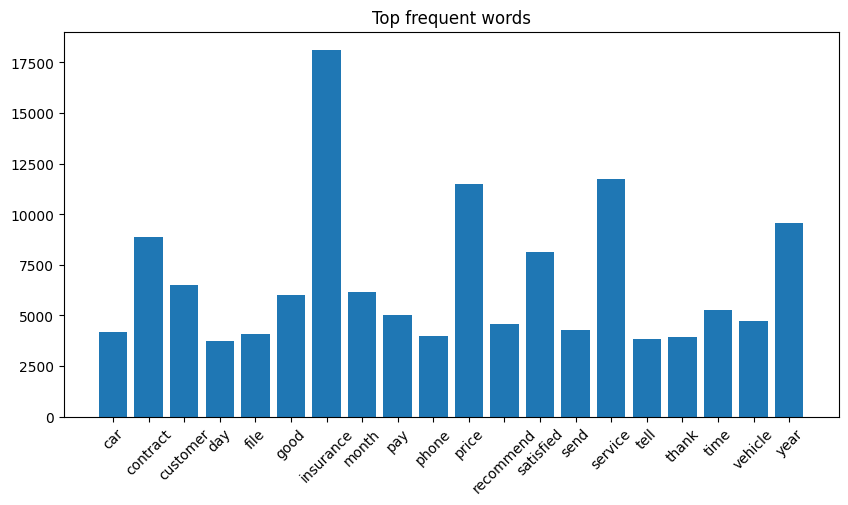

In [ ]:
df = pd.read_excel("data/reviews_clean.xlsx")
text_data = df["avis_spacy"].dropna()

vectorizer = CountVectorizer(
    max_features=20,
    ngram_range=(1,1)
)

X = vectorizer.fit_transform(text_data)
words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top frequent words")
plt.show()

### Nuage de mots : Highlight Words

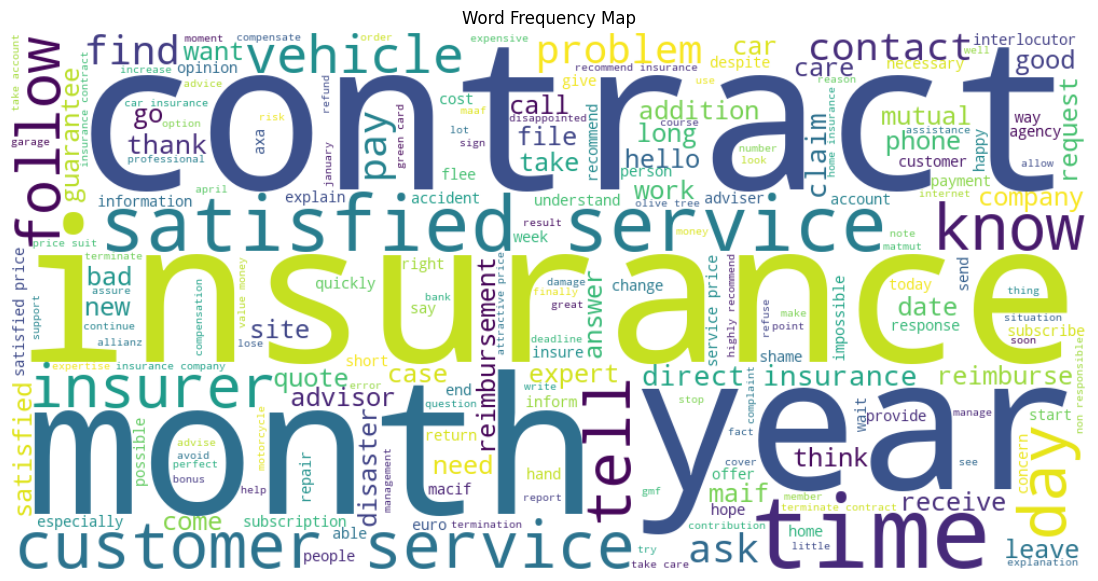

In [ ]:
text = " ".join(df["avis_spacy"].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
    #"plasma"
    #"coolwarm"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Frequency Map")
plt.show()

## 4) TF-IDF Retrieval

#### Product Prediction

Nous cherchons à prédire le produit associé à un avis client via une approche de retrieval basée sur TF-IDF, plutôt que via une classification classique. Chaque avis est comparé aux avis d’entraînement les plus similaires, et le produit est déterminé par vote majoritaire parmi les K voisins les plus proches.

Les catégories ont été simplifiées en regroupant les produits similaires (ex : auto et moto, santé/prévoyance/vie) afin de limiter les confusions. Nous avons ensuite conservé uniquement les produits disposant d’un volume suffisant de données (au moins 500 avis) et appliqué un undersampling pour équilibrer les classes.

Les avis sont vectorisés avec TF-IDF (unigrammes et bigrammes), puis la similarité cosinus est utilisée pour identifier les K voisins les plus proches (K=11). La prédiction correspond au produit majoritaire parmi ces voisins.

Interprétation :
- Pour la catégorie auto/moto, le mot important est fast, car les clients attendent un remboursement rapide, davantage que pour d’autres types d’assurance. 
- Pour le produit crédit, on retrouve le vocabulaire lié à la banque, à l’emprunt et au conseil. 
- Pour l’habitation, on observe des mots comme dégâts des eaux, damage, experts, désastres. 
- Pour la catégorie santé, prévoyance et vie, on remarque l’importance du contact et de la communication avec des mots comme phone, send, email, request, answer.

Products after merging:
  auto-moto                                     : 15787
  sante-prevoyance-vie                          : 4738
  habitation                                    : 1909
  credit                                        : 636
  animaux                                       : 362
  multirisque-professionnelle                   : 19
  garantie-decennale                            : 11
  assurances-professionnelles                   : 8
  responsabilite-civile-professionnelle         : 5
  flotte-automobile                             : 1

→ 4 products kept:

  Product                                         Train    Test
  ─────────────────────────────────────────────────────────────
  auto-moto                                       15787    6433
  credit                                            636     252
  habitation                                       1909     857
  sante-prevoyance-vie                             4738    2037

  Total → Train: 23070 | Test: 957

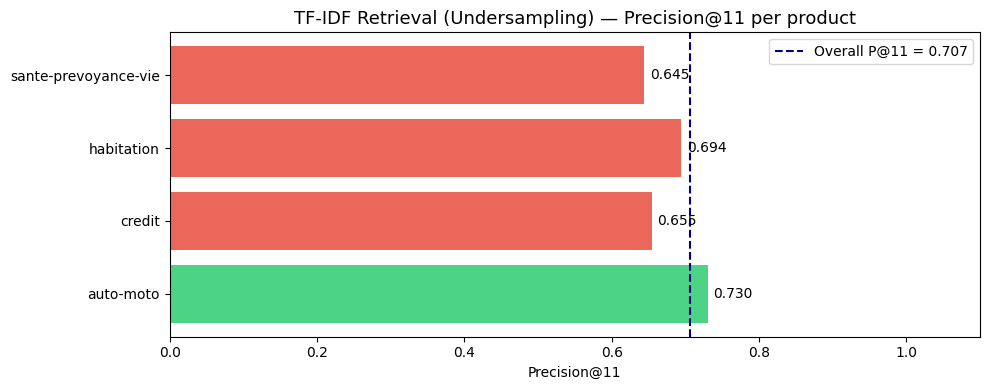


═════════════════════════════════════════════════════════════════
TOP WORDS PER CATEGORY (TF-IDF importance)
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
 PRODUCT : AUTO-MOTO
─────────────────────────────────────────────────────────────────
  price                     : 0.0588
  satisfied                 : 0.0481
  insurance                 : 0.0462
  service                   : 0.0401
  vehicle                   : 0.0309
  good                      : 0.0251
  recommend                 : 0.0244
  car                       : 0.0235
  contract                  : 0.0229
  customer                  : 0.0224
  fast                      : 0.0209
  thank                     : 0.0206
  satisfied service         : 0.0199
  year                      : 0.0197
  simple                    : 0.0188

─────────────────────────────────────────────────────────────────
 PRODUCT : CREDIT
──────────────────────────────

In [ ]:
# TF-IDF Retrieval
df = pd.read_excel("data/reviews_clean.xlsx")
#df = df[df["type"] == "train"].reset_index(drop=True)
df = df.dropna(subset=["avis_spacy"])
df["avis_spacy"] = df["avis_spacy"].astype(str).str.strip()
df = df[df["avis_spacy"].str.len() > 10]
df["type"]    = df["type"].astype(str).str.lower().str.strip()
df["produit"] = df["produit"].astype(str).str.strip()

# CATEGORY MERGING
MERGE_MAP = {
    "moto"       : "auto-moto",
    "auto"       : "auto-moto",
    "sante"      : "sante-prevoyance-vie",
    "prevoyance" : "sante-prevoyance-vie",
    "vie"        : "sante-prevoyance-vie",
}
df["produit"] = df["produit"].apply(lambda p: MERGE_MAP.get(p, p))
print("Products after merging:")
for p, n in df[df["type"] == "train"]["produit"].value_counts().items():
    print(f"  {p:<45} : {n}")

# FILTERING — products with >= 500 reviews in train
MIN_SAMPLES = 500
counts_train = df[df["type"] == "train"]["produit"].value_counts()
produits_valides = counts_train[counts_train >= MIN_SAMPLES].index.tolist()
train_df = df[(df["type"] == "train") & (df["produit"].isin(produits_valides))].copy().reset_index(drop=True)
test_df  = df[(df["type"] == "test")  & (df["produit"].isin(produits_valides))].copy().reset_index(drop=True)
produits   = sorted(produits_valides)
produit2id = {p: i for i, p in enumerate(produits)}
id2produit = {i: p for p, i in produit2id.items()}
train_df["label"] = train_df["produit"].map(produit2id)
test_df["label"]  = test_df["produit"].map(produit2id)

print(f"\n→ {len(produits)} products kept:")
print(f"\n  {'Product':<45} {'Train':>7} {'Test':>7}")
print(f"  {'─'*61}")
for p in produits:
    print(f"  {p:<45} {(train_df['produit']==p).sum():>7} {(test_df['produit']==p).sum():>7}")
print(f"\n  Total → Train: {len(train_df)} | Test: {len(test_df)}")

# UNDERSAMPLING
min_size    = train_df["label"].value_counts().min()
train_bal   = (train_df.groupby("label", group_keys=False)
                       .apply(lambda x: x.sample(min_size, random_state=42))
                       .reset_index(drop=True))

print(f"\nAfter undersampling → {min_size} reviews per class:")
for p in produits:
    print(f"  {p:<45} : {(train_bal['produit']==p).sum()}")
print(f"  Total : {len(train_bal)}")

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.90,
    min_df=2,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_bal["avis_spacy"].tolist())
X_test  = vectorizer.transform(test_df["avis_spacy"].tolist())
y_train = train_bal["label"].values
y_test  = test_df["label"].values

print(f"\nTF-IDF shape → Train: {X_train.shape} | Test: {X_test.shape}")

# RETRIEVAL FUNCTIONS
def topk_indices(doc_matrix, query_matrix, k: int) -> np.ndarray:
    sims  = (doc_matrix @ query_matrix.T).toarray().T
    k     = min(k, sims.shape[1])
    part  = np.argpartition(sims, -k, axis=1)[:, -k:]
    row   = np.arange(sims.shape[0])[:, None]
    order = np.argsort(sims[row, part], axis=1)[:, ::-1]
    return part[row, order]

# After undersampling, all classes are balanced → alphabetical tie-breaking
class_weights = {p_id: int((y_train == p_id).sum()) for p_id in id2produit}

def majority_label(lbls: list) -> int:
    counts     = {p_id: lbls.count(p_id) for p_id in id2produit}
    max_count  = max(counts.values())
    candidates = [p_id for p_id, c in counts.items() if c == max_count]
    if len(candidates) == 1:
        return candidates[0]
    return max(candidates, key=lambda p: class_weights[p])

# EVALUATION
K    = 11
topk = topk_indices(X_train, X_test, k=K)

y_pred = np.array([
    majority_label([y_train[i] for i in topk[qi]])
    for qi in range(len(y_test))
])

overall = float((y_pred == y_test).mean())

print(f"\nPrecision@{K} — Undersampling:")
print(f"  Overall : {overall:.4f}")
print()
print(f"  {'Product':<45} {'Precision':>10} {'Support':>10}")
print(f"  {'─'*67}")
for p_id, p_name in id2produit.items():
    mask = (y_test == p_id)
    if mask.sum() == 0:
        continue
    prec = float((y_pred[mask] == p_id).mean())
    print(f"  {p_name:<45} {prec:>10.4f} {mask.sum():>10}")

# VISUALIZATION
precisions = []
labels_viz = []
for p_id, p_name in id2produit.items():
    mask = (y_test == p_id)
    if mask.sum() == 0:
        continue
    precisions.append(float((y_pred[mask] == p_id).mean()))
    labels_viz.append(p_name)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ecc71" if p >= overall else "#e74c3c" for p in precisions]
bars   = ax.barh(labels_viz, precisions, color=colors, alpha=0.85)
ax.axvline(overall, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall P@{K} = {overall:.3f}")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel(f"Precision@{K}")
ax.set_title(f"TF-IDF Retrieval (Undersampling) — Precision@{K} per product", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

def top_words_per_class(X, y, id2produit, top_n=10):
    print(f"\n{'═'*65}")
    print("TOP WORDS PER CATEGORY (TF-IDF importance)")
    print(f"{'═'*65}")
    for class_id, class_name in id2produit.items():
        mask = (y == class_id)
        if mask.sum() == 0:
            continue
        mean_tfidf = X[mask].mean(axis=0).A1
        top_idx = np.argsort(mean_tfidf)[-top_n:][::-1]
        top_words = [(feature_names[i], mean_tfidf[i]) for i in top_idx]
        print(f"\n{'─'*65}")
        print(f" PRODUCT : {class_name.upper()}")
        print(f"{'─'*65}")
        for w, score in top_words:
            print(f"  {w:<25} : {score:.4f}")
feature_names = np.array(vectorizer.get_feature_names_out())
top_words_per_class(X_train, y_train, id2produit, top_n=15)

# EXAMPLE QUERIES — 3 per product
print(f"\n{'═'*65}")
print(f"EXAMPLE QUERIES — type=test (K={K}, Undersampling)")
print("═"*65)

for p_id, p_name in id2produit.items():
    indices = np.where(y_test == p_id)[0][:3]
    if len(indices) == 0:
        continue
    print(f"\n{'─'*65}")
    print(f"  TRUE PRODUCT : {p_name.upper()}")
    print(f"{'─'*65}")
    for rank, qi in enumerate(indices, 1):
        lbls      = [y_train[i] for i in topk[qi]]
        ret_lbls  = [id2produit[l] for l in lbls]
        predicted = id2produit[y_pred[qi]]
        correct   = "✓" if y_pred[qi] == y_test[qi] else "✗"
        print(f"\n  Example #{rank}:")
        print(f"  Query text       : {test_df['avis_en'].iloc[qi].replace(chr(10), ' ')}")
        print(f"  Top-{K} retrieved : {ret_lbls}")
        print(f"  → Predicted : {predicted}  {correct}")

## 5) TF-IDF + LDA (Latent Dirichlet Allocation)

#### Implémentation de la distance cosine

Nous appliquons une approche de topic modeling afin d’identifier automatiquement les thématiques présentes dans les avis clients. Les textes sont d’abord transformés en représentations numériques à l’aide d’une vectorisation TF-IDF et d’un comptage de mots (CountVectorizer), permettant de capturer l’importance des termes.

Un modèle de type LDA (Latent Dirichlet Allocation) est ensuite entraîné pour extraire un ensemble de topics latents. Chaque avis est représenté comme une combinaison de ces topics, et chaque topic est défini par un ensemble de mots représentatifs, ce qui permet une interprétation des thèmes principaux du corpus.

Les topics obtenus sont analysés via leurs mots les plus importants, leur distribution dans les données ainsi que leur relation avec les notes attribuées aux avis. Une visualisation sous forme de heatmap permet également d’illustrer l’importance des mots pour chaque topic.

Enfin, une évaluation basée sur le retrieval est réalisée en utilisant la similarité cosinus sur les représentations TF-IDF. L’objectif est de vérifier si les avis similaires partagent les mêmes topics dominants. Les performances sont mesurées via une métrique de type Precision@K, permettant d’évaluer la cohérence des topics à travers les documents similaires.

In [ ]:
df = pd.read_excel("data/reviews_clean.xlsx")
df = df.dropna(subset=["avis_spacy"])
df["avis_spacy"] = df["avis_spacy"].astype(str).str.strip()
df = df[df["avis_spacy"].str.len() > 10]
train_df = df[df["type"] == "train"].copy()
test_df  = df[df["type"] == "test"].copy()
print(f"Train: {len(train_df)} reviews | Test: {len(test_df)} reviews")
X_train = train_df["avis_spacy"].tolist()
X_test  = test_df["avis_spacy"].tolist()

# TF-IDF (on train)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.90,
    min_df=5,
    ngram_range=(1, 2)
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)
print(f"TF-IDF train shape: {X_train_tfidf.shape}")

# CountVectorizer (required for LDA)
count_vectorizer = CountVectorizer(
    max_features=5000,
    max_df=0.90,
    min_df=5,
    ngram_range=(1, 2)
)
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts  = count_vectorizer.transform(X_test)
feature_names  = count_vectorizer.get_feature_names_out()

# LDA — TRAINING
N_TOPICS = 6
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method="online",
    random_state=42,
    n_jobs=-1
)
lda.fit(X_train_counts)
train_topic_dist = lda.transform(X_train_counts)
test_topic_dist  = lda.transform(X_test_counts)
print(f"\nLDA trained | Perplexity (train): {lda.perplexity(X_train_counts):.2f}")

# TOPICS
N_TOP_WORDS = 12
TOPIC_LABELS = {
    0: "Contracts & Reimbursements",
    1: "Claims & Compensation",
    2: "Customer Service",
    3: "Price & Subscription",
    4: "File Management",
    5: "General Satisfaction",
}

def print_topics(model, feature_names, n_top=N_TOP_WORDS):
    print("\n── DETECTED TOPICS ──")
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        label = TOPIC_LABELS.get(idx, f"Topic {idx}")
        print(f"\nTopic {idx} [{label}]:")
        print("  " + " | ".join(top_words))

print_topics(lda, feature_names)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 6))

top_words_per_topic = []
for topic in lda.components_:
    top_idx = topic.argsort()[:-N_TOP_WORDS - 1:-1]
    top_words_per_topic.append([feature_names[i] for i in top_idx])

all_top_words = list(dict.fromkeys(
    w for words in top_words_per_topic for w in words
))

heatmap_data = np.zeros((N_TOPICS, len(all_top_words)))
for t_idx, topic in enumerate(lda.components_):
    for w_idx, word in enumerate(all_top_words):
        vocab_idx = np.where(feature_names == word)[0]
        if len(vocab_idx) > 0:
            heatmap_data[t_idx, w_idx] = topic[vocab_idx[0]]

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=[TOPIC_LABELS.get(i, f"Topic {i}") for i in range(N_TOPICS)],
    columns=all_top_words
)
heatmap_norm = heatmap_df.div(heatmap_df.max(axis=1), axis=0)

sns.heatmap(heatmap_norm, cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Relative importance"})
ax.set_title("Heatmap of most important words per Topic", fontsize=14, pad=12)
ax.set_xlabel("Words / Bigrams")
ax.set_ylabel("Topics")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

# Distribution of dominant topics
dominant_topics = train_topic_dist.argmax(axis=1)
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
colors = cm.tab10(np.linspace(0, 1, N_TOPICS))
bars = ax.bar(
    [TOPIC_LABELS.get(i, f"Topic {i}") for i in topic_counts.index],
    topic_counts.values,
    color=colors[:len(topic_counts)]
)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("Distribution of dominant Topics", fontsize=13)
ax.set_ylabel("Number of reviews")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Topics by rating
train_df = train_df.copy()
train_df["dominant_topic"] = dominant_topics
train_df["dominant_topic_label"] = train_df["dominant_topic"].map(TOPIC_LABELS)

if "note" in train_df.columns:
    pivot = train_df.groupby(["note", "dominant_topic_label"]).size().unstack(fill_value=0)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_norm.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
    ax.set_title("Topic distribution by rating (stars)", fontsize=13)
    ax.set_xlabel("Rating (stars)")
    ax.set_ylabel("Proportion")
    ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ADD COLUMNS TO DATAFRAME
all_counts     = count_vectorizer.transform(df["avis_spacy"].tolist())
all_topic_dist = lda.transform(all_counts)

df["dominant_topic"]       = all_topic_dist.argmax(axis=1)
df["dominant_topic_label"] = df["dominant_topic"].map(TOPIC_LABELS)

for i in range(N_TOPICS):
    df[f"topic_{i}_prob"] = all_topic_dist[:, i]

print("\n── Columns added to DataFrame ──")
print(df[["avis_spacy", "dominant_topic", "dominant_topic_label"]].head(5))

# COHERENCE ON TEST
test_dominant = test_topic_dist.argmax(axis=1)
test_df = test_df.copy()
test_df["dominant_topic"]       = test_dominant
test_df["dominant_topic_label"] = test_df["dominant_topic"].map(TOPIC_LABELS)

print("\n── Topic distribution on TEST ──")
print(test_df["dominant_topic_label"].value_counts())

# TF-IDF RETRIEVAL EVALUATION (Precision@K)
#    Goal: a TEST query should retrieve TRAIN docs
#    with the same dominant topic
def topk_indices(doc_matrix, query_matrix, k: int) -> np.ndarray:
    """
    Top-K indices by cosine similarity.
    TF-IDF sklearn is L2-normalized → cosine = dot product.
    Returns shape (n_queries, k).
    """
    sims = (doc_matrix @ query_matrix.T).toarray().T
    k    = min(k, sims.shape[1])
    part = np.argpartition(sims, -k, axis=1)[:, -k:]
    row  = np.arange(sims.shape[0])[:, None]
    order = np.argsort(sims[row, part], axis=1)[:, ::-1]
    return part[row, order]

def precision_at_k(retrieved_idx: np.ndarray,
                   doc_labels: np.ndarray,
                   query_labels: np.ndarray) -> float:
    """
    Average Precision@K: fraction of top-K docs whose
    label (dominant topic) matches the query label.
    """
    retrieved_labels = doc_labels[retrieved_idx]
    matches = (retrieved_labels == query_labels[:, None]).mean(axis=1)
    return float(matches.mean())

print("\n── TF-IDF Retrieval Evaluation (Precision@K) ──")

y_train_topics = train_topic_dist.argmax(axis=1)
y_test_topics  = test_topic_dist.argmax(axis=1)

K    = 10
topk = topk_indices(X_train_tfidf, X_test_tfidf, k=K)

overall_p = precision_at_k(topk, y_train_topics, y_test_topics)

print(f"\nPrecision@{K} (topic match):")
print(f"  Overall: {overall_p:.4f}")

for t in range(N_TOPICS):
    mask = (y_test_topics == t)
    if mask.sum() == 0:
        continue
    p = precision_at_k(topk[mask], y_train_topics, y_test_topics[mask])
    print(f"  Topic {t} [{TOPIC_LABELS[t]}]: {p:.4f}  (n={mask.sum()})")

# Query example
print(f"\nQuery Example (index 0):")
qi = 0
retrieved      = topk[qi]
true_topic     = TOPIC_LABELS[y_test_topics[qi]]
retrieved_topics = [TOPIC_LABELS[y_train_topics[i]] for i in retrieved]

print(f"  Query topic: {true_topic}")
print(f"  Query text: {X_test[qi][:220].replace(chr(10), ' ')} ...")
print(f"  Top-{K} retrieved topics:")
for rank, rt in enumerate(retrieved_topics, 1):
    match = "✓" if rt == true_topic else "✗"
    print(f"    {rank:2d}. {match} {rt}")

# Visualization Precision@K by topic
topic_precisions = []
for t in range(N_TOPICS):
    mask = (y_test_topics == t)
    if mask.sum() == 0:
        topic_precisions.append(0.0)
    else:
        topic_precisions.append(
            precision_at_k(topk[mask], y_train_topics, y_test_topics[mask])
        )

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#2ecc71" if p >= overall_p else "#e74c3c" for p in topic_precisions]
bars = ax.barh(
    [TOPIC_LABELS[i] for i in range(N_TOPICS)],
    topic_precisions,
    color=bar_colors
)
ax.axvline(overall_p, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall P@{K} = {overall_p:.3f}")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlim(0, 1)
ax.set_xlabel(f"Precision@{K}")
ax.set_title(f"TF-IDF Retrieval — Precision@{K} by Topic", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅ Topic Modeling + Retrieval Evaluation completed.")

## 6) Word Embeddings + Gensim

#### Insurance Recommandation

Nous nous sommes inspiré du projet 1 sur des reviews tripadvisor et appliqué la méthode Gensim vu en LAB, nous avons créer un system de recommendation d'assurance en fonction de leur similarité.

Nous avons également utilisé des word embeddings en nous inspirant du premier projet : nous regroupons les avis par assureur et construisons un modèle qui recommande l’assurance la plus similaire en mettant en avant les mots importants. Nous passons rapidement dessus car nous avons déjà réalisé un projet complet sur ce sujet.

### Gensim Preparation

In [ ]:
#!pip install gensim
import gensim.downloader
import pickle
import os

class gensim_interface:

    """
    #List of possible embeddings:

    ['fasttext-wiki-news-subwords-300',
     'conceptnet-numberbatch-17-06-300',
     'word2vec-ruscorpora-300',
     'word2vec-google-news-300',
     'glove-wiki-gigaword-50',
     'glove-wiki-gigaword-100',
     'glove-wiki-gigaword-200',
     'glove-wiki-gigaword-300',
     'glove-twitter-25',
     'glove-twitter-50',
     'glove-twitter-100',
     'glove-twitter-200',
     '__testing_word2vec-matrix-synopsis']
    """

    #load and serialize the embeddings in order to accelerate next loads
    #input: name of the embedding wanted (example : 'glove-twitter-25')
    #output: the vector embeddings
    def embeddingPreparation(self,embeddingName):
        self.embeddingVectors = gensim.downloader.load(embeddingName)
        with open(embeddingName + ".vecs","wb") as fd:
            pickle.dump(self.embeddingVectors,fd)
        #return self.embeddingVectors

    #load already serialized embeddings (call of embeddingPreparation() needed before)
    #input: name of the embedding wanted (example : 'glove-twitter-25')
    #output: the vector embeddings
    def loadPreparedEmbedding(self,embeddingName):
        with open(embeddingName + ".vecs","rb") as fd:
            self.embeddingVectors = pickle.load(fd)
        #return self.embeddingVectors

    #input: word or id of the word
    #output: True if word in the embedding list, False otherwise
    def isVec(self,word):
        if word in self.embeddingVectors:
            return True
        else:
            return False

    #input: word(string) or word id(int)
    #output: vector embedding
    def getVec(self,word):
        return self.embeddingVectors[word]

    #input: word(string)
    #output: word id(int)
    def getId(self,word):
        return self.embeddingVectors.key_to_index[word]

    #input: word id(int)
    #output: word(string)
    def getWord(self,id):
        return self.embeddingVectors.index_to_key[id]

    #output : list of all words covered by the embedding
    def getVocabList(self):
        return self.embeddingVectors.index_to_key

    #output : return vocabulary dictionary associating word and idWords (key=word, value=idWord)
    def getVocabDic(self):
        return self.embeddingVectors.key_to_index

    #output : number of words covered by the embedding
    def getLenVocab(self):
        return len(self.embeddingVectors.index_to_key)

    #output :  number of dimensions of the embedding
    def nbDims(self):
        return self.embeddingVectors.vector_size

    #output : list of all embeddings names availables on gensim
    def getAvailableEmbeddings(self):
        return list(gensim.downloader.info()['models'].keys())

    #input : word , number of most similar words wanted
    #output : list of n most similar words
    def getMostSimilar(self,word,n):
        ms = self.embeddingVectors.most_similar(word,topn=n)
        neighbours = [elem[0] for elem in ms]
        return neighbours

    ########################################################
    ########################################################
    ########################################################

    def __init__(self,embeddingName):
        #test if file exists
        fileName = embeddingName + ".vecs"
        if os.path.isfile(fileName):
            print("loading embeddings...")
            self.loadPreparedEmbedding(embeddingName)
        else:
            print("embedding preparation...")
            self.embeddingPreparation(embeddingName)
        self.vectors = self.embeddingVectors.vectors

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_excel("data/reviews_clean.xlsx")
# df = df[df["type"] == "train"].reset_index(drop=True)
df = df.dropna(subset=["avis_spacy"])
df["avis_spacy"] = df["avis_spacy"].astype(str)
emb = gensim_interface('model/glove-wiki-gigaword-100')

grouped = df.groupby('assureur')['avis_spacy'].apply(
    lambda x: " ".join(x)
).reset_index()

X_train02, X_test02 = train_test_split(
    grouped,
    test_size=0.1,
    random_state=42
)
X_train02 = X_train02.reset_index(drop=True)
X_test02 = X_test02.reset_index(drop=True)

def get_document_embedding(text, emb):
    words = text.split()
    vectors = []
    for word in words:
        if emb.isVec(word):
            vectors.append(emb.getVec(word))
    if len(vectors) == 0:
        return np.zeros(emb.nbDims())
    return np.mean(vectors, axis=0)

train_embeddings = []
for text in X_train02['avis_spacy']:
    train_embeddings.append(
        get_document_embedding(text, emb)
    )
train_embeddings = np.array(train_embeddings)

test_embeddings = []
for text in X_test02['avis_spacy']:
    test_embeddings.append(
        get_document_embedding(text, emb)
    )
test_embeddings = np.array(test_embeddings)

similarity_matrix_m02 = cosine_similarity(
    test_embeddings,
    train_embeddings
)

np.save("data/train_embeddings.npy", train_embeddings)
np.save("data/test_embeddings.npy", test_embeddings)
np.save("data/similarity_matrix.npy", similarity_matrix_m02)

def explain_similarity_words(query_text, similar_text, emb,
                             top_k_words=8,
                             threshold=0.5):
    query_words = list(set(query_text.split()))
    similar_words = list(set(similar_text.split()))
    matched_pairs = []
    for w1 in query_words:
        if not emb.isVec(w1):
            continue
        v1 = emb.getVec(w1)
        for w2 in similar_words:
            if not emb.isVec(w2):
                continue
            v2 = emb.getVec(w2)
            sim = np.dot(v1, v2) / (
                np.linalg.norm(v1) * np.linalg.norm(v2)
            )
            if sim > threshold:
                matched_pairs.append((w1, w2, sim))
    matched_pairs = sorted(
        matched_pairs,
        key=lambda x: x[2],
        reverse=True
    )
    return matched_pairs[:top_k_words]

def recommend_similar_insurance_extended(assureur_query,
                                         top_k=3,
                                         top_n_words=5,
                                         df_reviews=df):
    if assureur_query not in df_reviews['assureur'].values:
        return "Insurance company not found in dataset"
    
    avg_rating = df_reviews[df_reviews['assureur'] == assureur_query]['note'].mean()
    products = df_reviews[df_reviews['assureur'] == assureur_query]['produit'].unique()
    
    print(f"Query Insurance Company: {assureur_query}")
    print(f"Average Rating: {avg_rating:.2f}")
    print(f"Products Covered: {', '.join(products)}")
    
    X_test_reset = X_test02.reset_index(drop=True)
    X_train_reset = X_train02.reset_index(drop=True)
    
    if assureur_query not in X_test_reset['assureur'].values:
        print("Warning: Insurance company not in test set, using closest from train set for similarity")
        query_idx = 0
    else:
        query_idx = X_test_reset.index[
            X_test_reset['assureur'] == assureur_query
        ][0]
    
    sims = similarity_matrix_m02[query_idx].copy()
    top_indices_sim = np.argsort(sims)[::-1][:top_k]
    query_text = X_test_reset.iloc[query_idx]['avis_spacy']
    
    print("\nTop Recommendations:")
    
    recommendations = []
    for rank, idx in enumerate(top_indices_sim, start=1):
        rec_assureur = X_train_reset.iloc[idx]['assureur']
        score = sims[idx]
        rec_products = df_reviews[df_reviews['assureur'] == rec_assureur]['produit'].unique()
        similar_text = X_train_reset.iloc[idx]['avis_spacy']
        
        print(f"\nRecommendation {rank}: {rec_assureur}")
        avg_rating = df_reviews[df_reviews['assureur'] == rec_assureur]['note'].mean()
        print(f"Average Rating: {avg_rating:.2f}")
        print(f"Similarity Score: {score:.3f}")
        print(f"Products Covered: {', '.join(rec_products)}")
        
        matched_words = explain_similarity_words(
            query_text,
            similar_text,
            emb,
            top_k_words=top_n_words
        )
        
        print("Top Matching Words:")
        if len(matched_words) == 0:
            print(" - No strong semantic match found")
        else:
            for w1, w2, sim in matched_words:
                print(f" - {w1}")
        
        recommendations.append(rec_assureur)
    return recommendations

print("Insurance companies in test set:")
print(X_test02['assureur'].tolist())
assureur_test = "MAIF"
print("\nRecommendations for insurance company:", assureur_test)
recs = recommend_similar_insurance_extended(assureur_test)

loading embeddings...
Insurance companies in test set:
['AMV', 'Afer', 'MAIF', 'Carac', 'Euro-Assurance', 'Sogecap']

Recommendations for insurance company: MAIF
Query Insurance Company: MAIF
Average Rating: 1.83
Products Covered: auto, habitation

Top Recommendations:

Recommendation 1: MACIF
Average Rating: 1.80
Similarity Score: 0.999
Products Covered: moto, habitation, auto, vie, prevoyance
Top Matching Words:
 - proud
 - stagnate
 - systematically
 - tick
 - action

Recommendation 2: Matmut
Average Rating: 1.99
Similarity Score: 0.999
Products Covered: auto, habitation
Top Matching Words:
 - proud
 - systematically
 - action
 - naively
 - kindness

Recommendation 3: Pacifica
Average Rating: 1.93
Similarity Score: 0.998
Products Covered: habitation, auto
Top Matching Words:
 - systematically
 - action
 - intimidate
 - kindness
 - establishment


## 7) Semantic Search et ACP (Analyse par Composantes Principales)

#### Word2Vec & Glove

Nous avons exploité les word embeddings pour mettre en place un système de semantic search, permettant de retrouver des avis similaires à une requête en langage naturel.

Chaque texte est représenté sous forme de vecteur en agrégeant les embeddings des mots qui le composent (moyenne des vecteurs Word2Vec ou GloVe). Une requête utilisateur est transformée de la même manière, puis comparée à l’ensemble des avis via la similarité cosinus.

Le système retourne les avis les plus proches sémantiquement de la requête, même en l’absence de mots identiques, ce qui permet de capturer le sens global plutôt qu’un simple matching lexical. Nous avons appliqué cette approche avec des embeddings Word2Vec entraînés sur le dataset ainsi que des embeddings pré-entraînés GloVe, afin de comparer leur comportement.

Ce type d’approche constitue une base de recherche sémantique efficace, permettant de retrouver des contenus proches en fonction du sens des phrases plutôt que des mots exacts.

Sur la PCA, on observe que les deux modèles capturent plutôt bien les relations entre cheap, expensive et price. Word2Vec capture un peu mieux la relation claim, damage, accident, tandis que GloVe est plus performant sur fast, slow, good, bad.

Corpus: 23476 reviews | 551502 tokens

── Word2Vec (trained on the dataset) ──
Word2Vec vocabulary size: 4709 words

Most similar words (Word2Vec):
insurance       → ['assurance', 'insurer', 'debit', 'asurance', 'newcomer', 'avanssur', 'personally', 'inadequacy']
claim           → ['disaster', 'incident', 'sinister', 'accident', 'glitch', 'dispute', 'loss', 'clash']
price           → ['rate', 'pricing', 'relatively', 'tariff', 'slightly', 'compare', 'significantly', 'range']
service         → ['relation', 'satisfy', 'area', 'department', 'monitoring', 'relationship', 'adviser', 'impeccable']
policy          → ['alteration', 'alter', 'beware', 'reward', 'loyalty', 'amaguiz', 'bait', 'unlike']

── Pretrained GloVe (glove-wiki-gigaword-100) ──
loading embeddings...
GloVe vocabulary: 400000 words | 100 dimensions

Most similar words (GloVe):
insurance       → ['insurers', 'pension', 'premiums', 'care', 'insurer', 'savings', 'credit', 'health']
price           → ['prices', 'value', 'drop', 

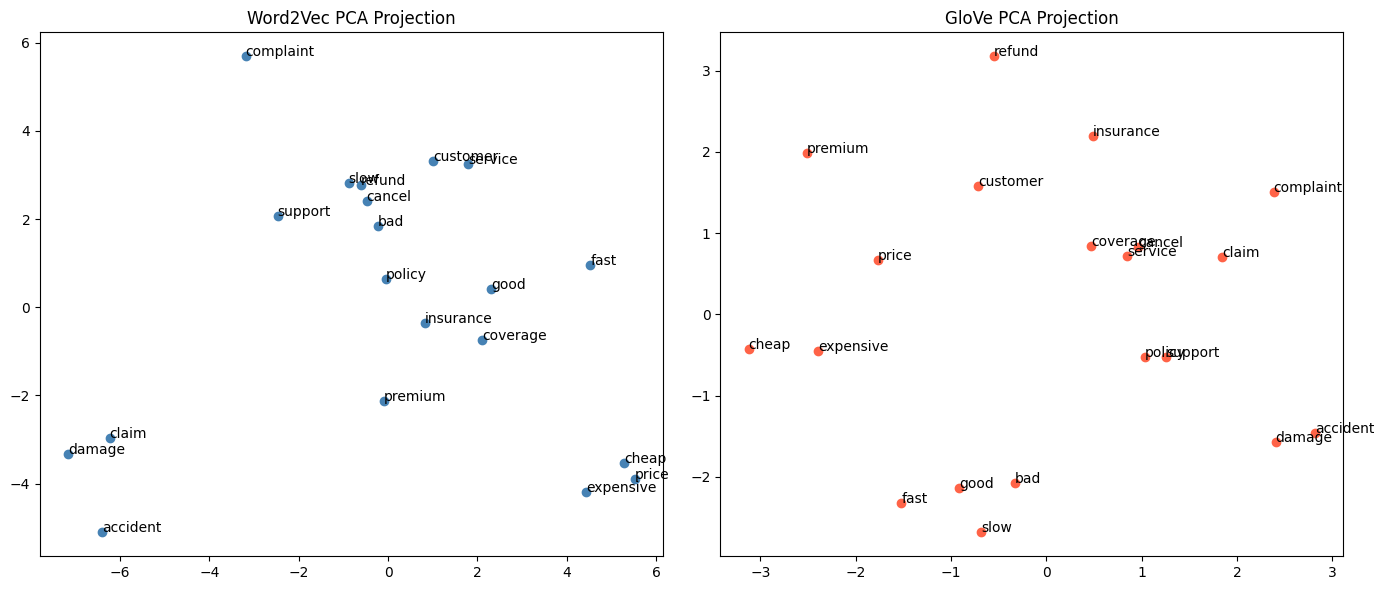


Word embeddings processing completed.

═════════════════════════════════════════════════════════════════
  SEMANTIC SEARCH (BONUS)
═════════════════════════════════════════════════════════════════

── Query: "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"

  [Word2Vec]
  #1 (score=0.9265, rating=3.0)
      I am satisfied with the speaker, a quick service. Price level is honest. This is my second vehicle insured with the Olivier Insurance, if I was not satisfied, I would have changed insurance. ...
  #2 (score=0.9255, rating=4.0)
      I am satisfied with the quality/price ratio. I opted for direct insurance as 1st car insurance. I am satisfied with it. Hoping that this continues ...
  #3 (score=0.9189, rating=4.0)
      I am satisfied with the conditions Correct price for vehicle insurance as for housing I recommend direct insurance We are looking for fast 

In [ ]:
df = pd.read_excel("data/reviews_clean.xlsx")
df = df[df["type"] == "train"].reset_index(drop=True)
df = df.dropna(subset=["avis_spacy"])
df["avis_spacy"] = df["avis_spacy"].astype(str).str.strip()
df = df[df["avis_spacy"].str.len() > 10]
sentences = [text.split() for text in df["avis_spacy"].tolist()]
print(f"Corpus: {len(sentences)} reviews | {sum(len(s) for s in sentences)} tokens")

# WORD2VEC TRAINING
print("\n── Word2Vec (trained on the dataset) ──")
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)
w2v_model.save("model/word2vec_reviews.model")
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)} words")

# WORD2VEC SIMILAR WORDS
TEST_WORDS_W2V = [
    "insurance",
    "claim",
    "price",
    "service",
    "policy"
]
print("\nMost similar words (Word2Vec):")

for word in TEST_WORDS_W2V:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=8)
        print(f"{word:<15} → {[w for w,_ in similar]}")
    else:
        print(f"{word:<15} → not in vocabulary")

# GLOVE — via gensim_interface
print("\n── Pretrained GloVe (glove-wiki-gigaword-100) ──")
glove = gensim_interface("glove-wiki-gigaword-100")
print(f"GloVe vocabulary: {glove.getLenVocab()} words | {glove.nbDims()} dimensions")
TEST_WORDS_GLOVE = ["insurance","price","service","claim","accident"]
print("\nMost similar words (GloVe):")

for word in TEST_WORDS_GLOVE:
    if glove.isVec(word):
        similar = glove.getMostSimilar(word,8)
        print(f"{word:<15} → {similar}")
    else:
        print(f"{word:<15} → not in vocabulary")

# COSINE & EUCLIDEAN DISTANCES
def cosine_distance(v1,v2):
    dot = np.dot(v1,v2)
    norm = np.linalg.norm(v1)*np.linalg.norm(v2)
    return 1 - (dot/norm) if norm>0 else 1

def euclidean_distance(v1,v2):
    return float(np.sqrt(np.sum((v1-v2)**2)))

PAIRS = [
    ("insurance","coverage"),
    ("insurance","policy"),
    ("price","expensive"),
    ("service","customer"),
    ("good","bad")
]
print("\nDistances between word pairs")
print(f"\n{'Pair':<30} {'Cosine W2V':>12} {'Euclid W2V':>12} {'Cosine GloVe':>14} {'Euclid GloVe':>14}")

for w1,w2 in PAIRS:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        v1_w = w2v_model.wv[w1]
        v2_w = w2v_model.wv[w2]
        cos_w = cosine_distance(v1_w,v2_w)
        euc_w = euclidean_distance(v1_w,v2_w)
    else:
        cos_w = euc_w = float("nan")
    if glove.isVec(w1) and glove.isVec(w2):
        v1_g = glove.getVec(w1)
        v2_g = glove.getVec(w2)
        cos_g = cosine_distance(v1_g,v2_g)
        euc_g = euclidean_distance(v1_g,v2_g)
    else:
        cos_g = euc_g = float("nan")
    print(f"{str((w1,w2)):<30} {cos_w:>12.4f} {euc_w:>12.4f} {cos_g:>14.4f} {euc_g:>14.4f}")
    
# PCA VISUALIZATION
def plot_embeddings_pca(embeddings_dict, words, title, ax, color):
    vectors = [embeddings_dict[w] for w in words if w in embeddings_dict]
    valid_words = [w for w in words if w in embeddings_dict]
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)
    x = reduced[:, 0]
    y = reduced[:, 1]
    ax.scatter(x, y, color=color)
    for i, word in enumerate(valid_words):
        ax.annotate(word, (x[i], y[i]))
    ax.set_title(title)

VIZ_WORDS = [
"insurance","policy","coverage","premium",
"claim","accident","damage",
"price","expensive","cheap",
"service","customer","support",
"refund","cancel","complaint",
"good","bad","fast","slow"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Word2Vec
plot_embeddings_pca(
    {w: w2v_model.wv[w] for w in VIZ_WORDS if w in w2v_model.wv},
    VIZ_WORDS,
    "Word2Vec PCA Projection",
    axes[0],
    color="steelblue"
)

# GloVe
glove_wv = {w: glove.getVec(w) for w in VIZ_WORDS if glove.isVec(w)}

plot_embeddings_pca(
    glove_wv,
    list(glove_wv.keys()),
    "GloVe PCA Projection",
    axes[1],
    color="tomato"
)

plt.tight_layout()
plt.show()

print("\nWord embeddings processing completed.")

# SEMANTIC SEARCH (BONUS)
# Free text query → most similar reviews
# using average Word2Vec / GloVe vectors

def get_sentence_vector(text, model):
    """
    Represent a sentence as the average of its word vectors.
    Works with both Word2Vec and gensim_interface GloVe.
    """
    tokens = text.lower().split()
    vectors = []
    for word in tokens:
        # Word2Vec case
        if hasattr(model, "__contains__") and word in model:
            vectors.append(model[word])
        # GloVe (gensim_interface) case
        elif hasattr(model, "isVec") and model.isVec(word):
            vectors.append(model.getVec(word))
    if len(vectors) == 0:
        return None
    return np.mean(vectors, axis=0)

def cosine_similarity(v1, v2):
    """
    Cosine similarity between two vectors.
    1 = identical, 0 = orthogonal.
    """
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    if norm == 0:
        return 0.0
    return float(np.dot(v1, v2) / norm)

def semantic_search(query, texts, model, top_k=5):
    """
    Semantic search:
    returns the top_k reviews most similar to the query.
    """
    query_vec = get_sentence_vector(query, model)
    if query_vec is None:
        print("  ⚠ No query words found in the vocabulary.")
        return []
    scores = []
    for idx, text in enumerate(texts):
        doc_vec = get_sentence_vector(text, model)
        if doc_vec is None:
            continue
        similarity = cosine_similarity(query_vec, doc_vec)
        scores.append((idx, similarity))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

print("\n" + "═" * 65)
print("  SEMANTIC SEARCH (BONUS)")
print("═" * 65)
# Use avis_en for readable results
texts_search = df["avis_en"].fillna("").astype(str).tolist()
# Use avis_spacy for vector computation
texts_spacy  = df["avis_spacy"].fillna("").astype(str).tolist()
QUERIES = [
    "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment",
    #"Olivier insurance is a very good insurance I am satisfied with it, quality question and price it suits me very well. I recommend everyone",
    "The price is attractive compared to my situation, formulas twice and a half times cheaper for an identical formula compared to my preceding insurer",
    "I am satisfied with your services, easy to use, very affordable price. Quick and easy response to understanding, signature of the online contract very satisfactory.",
    #"I am satisfied with the service and the commercial proposal The request was taken into account quickly I recommend this insurance because they are fast",
    #"Correct and fast price nothing to say we will see later if in the event of a claim this insurer this quickly and reliable shows the continuation to the next episodes. Thanks"
]

for query in QUERIES:
    print(f"\n── Query: \"{query}\"")
    # Word2Vec results
    print("\n  [Word2Vec]")
    results_w2v = semantic_search(query, texts_spacy, w2v_model.wv, top_k=3)
    for rank, (idx, score) in enumerate(results_w2v, 1):
        review_text = texts_search[idx][:200].replace("\n", " ")
        note = df["note"].iloc[idx] if "note" in df.columns else "?"
        print(f"  #{rank} (score={score:.4f}, rating={note})")
        print(f"      {review_text} ...")

    # GloVe results
    print("\n  [GloVe]")
    results_glove = semantic_search(query, texts_spacy, glove, top_k=3)
    for rank, (idx, score) in enumerate(results_glove, 1):
        review_text = texts_search[idx][:200].replace("\n", " ")
        note = df["note"].iloc[idx] if "note" in df.columns else "?"
        print(f"  #{rank} (score={score:.4f}, rating={note})")
        print(f"      {review_text} ...")

# Word2Vec vs GloVe comparison on same query
print("\n── Word2Vec vs GloVe comparison ──")
query_cmp = "The price is attractive compared to my situation, formulas twice and a half times cheaper for an identical formula compared to my preceding insurer"
results_w2v   = semantic_search(query_cmp, texts_spacy, w2v_model.wv, top_k=100)
results_glove = semantic_search(query_cmp, texts_spacy, glove, top_k=100)
idx_w2v   = set(i for i, _ in results_w2v)
idx_glove = set(i for i, _ in results_glove)
overlap = idx_w2v & idx_glove

print(f"  Query         : \"{query_cmp}\"")
print(f"  Word2Vec hits : {sorted(idx_w2v)}")
print(f"  GloVe hits    : {sorted(idx_glove)}")
print(f"  Overlap       : {len(overlap)}/100 shared reviews")

## 8) TF-IDF + Logistic Regression

#### Number of Stars Prediction

Nous avons mis en place un modèle permettant de prédire la note (1 à 5 étoiles) associée à un avis client à partir de son contenu textuel.

Les textes sont vectorisés avec TF-IDF, puis utilisés pour entraîner un modèle de régression logistique. Un Grid Search a été réalisé afin d’optimiser les hyperparamètres, avec notamment le solveur lbfgs comme meilleur choix.

Les résultats montrent que le modèle parvient globalement à distinguer les avis positifs et négatifs, mais qu’il confond encore certaines classes proches, en particulier les notes 1 et 2 d’une part, et 4 et 5 d’autre part. Cela s’explique par des similarités lexicales entre ces classes : les avis négatifs contiennent souvent des mots comme no, not, tandis que les avis positifs utilisent des termes comme satisfied, fast, recommend.

Les avis neutres (note 3) sont plus difficiles à classifier car ils mélangent vocabulaire positif et négatif. Enfin, on observe que les avis négatifs sont souvent plus variés et moins structurés, avec davantage de mots peu informatifs, alors que les avis positifs tendent à être plus directs et homogènes dans leur formulation.

Accuracy : 0.5086666666666667
MAE      : 0.61
RMSE     : 0.9377277501137168
F1 Macro : 0.5039010769951042

Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.61      0.57       300
           2       0.45      0.47      0.46       300
           3       0.45      0.36      0.40       300
           4       0.47      0.43      0.45       300
           5       0.61      0.67      0.64       300

    accuracy                           0.51      1500
   macro avg       0.50      0.51      0.50      1500
weighted avg       0.50      0.51      0.50      1500



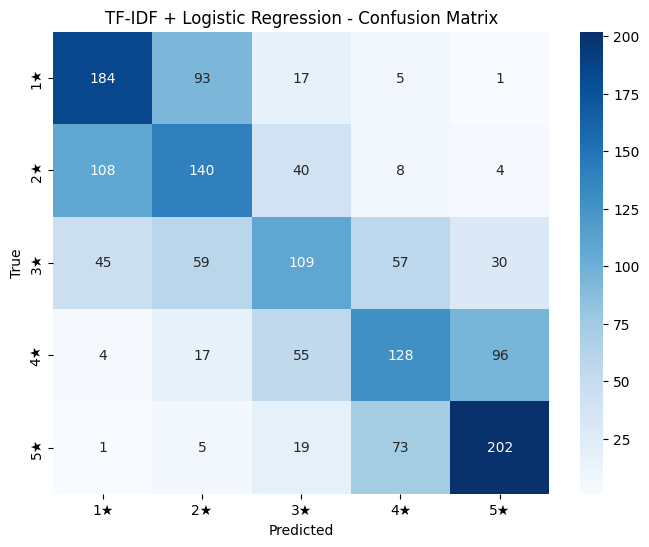


Top 10 words — 1★
----------------------------------------
  not                       : 0.0537
  no                        : 0.0481
  they                      : 0.0325
  you                       : 0.0282
  in                        : 0.0278
  that                      : 0.0222
  this                      : 0.0177
  on                        : 0.0176
  them                      : 0.0153
  by                        : 0.0142

Top 10 words — 2★
----------------------------------------
  not                       : 0.0713
  no                        : 0.0336
  on                        : 0.0214
  that                      : 0.0197
  it                        : 0.0193
  for                       : 0.0188
  in                        : 0.0181
  an                        : 0.0138
  you                       : 0.0131
  but                       : 0.0129

Top 10 words — 3★
----------------------------------------
  but                       : 0.0239
  satisfied                 : 0.0225
  am  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    f1_score,
    classification_report,
    confusion_matrix
)

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_excel("data/reviews_nlp.xlsx")
df = df[df["type"] == "train"].reset_index(drop=True)
df["label"] = df["note"] - 1
df = df.dropna()
df['note'] = df['note'].astype(int)

X = df['avis_cor']
y = df['note']

# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=df["label"]
)

# ── MODEL ─────────────────────────────────────────────────────────────────────
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        max_df=0.5,
        min_df=5
    )),
    ("logreg", LogisticRegression(
        max_iter=1000,
        C=0.5,
        solver="lbfgs",
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── METRICS ───────────────────────────────────────────────────────────────────
acc_tfidf  = accuracy_score(y_test, y_pred)
mae_tfidf  = mean_absolute_error(y_test, y_pred)
rmse_tfidf = np.sqrt(mean_squared_error(y_test, y_pred))
f1_tfidf   = f1_score(y_test, y_pred, average="macro")

print("Accuracy :", acc_tfidf)
print("MAE      :", mae_tfidf)
print("RMSE     :", rmse_tfidf)
print("F1 Macro :", f1_tfidf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title):
    cm          = confusion_matrix(y_true, y_pred)
    labels      = sorted(list(set(y_true)))
    labels_star = [f"{i}★" for i in labels]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_star, yticklabels=labels_star)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_confusion_matrix(y_test, y_pred, "TF-IDF + Logistic Regression - Confusion Matrix")

# ── DISPLAY HELPER ────────────────────────────────────────────────────────────
def print_top_words(words_with_scores, title):
    print(f"\n{title}")
    print("-" * 40)
    for word, score in words_with_scores:
        print(f"  {word:<25} : {score:.4f}")

# ── TOP 10 WORDS PER CLASS via LogReg coefficients ───────────────────────────
def get_top_words_per_class(model, class_names, n_words=10):
    """
    Use LogReg coefficients × mean TF-IDF scores to get the most
    representative words per class.
    """
    tfidf         = model.named_steps['tfidf']
    logreg        = model.named_steps['logreg']
    feature_names = tfidf.get_feature_names_out()

    # Mean TF-IDF scores across all training documents
    X_train_tfidf = tfidf.transform(X_train)
    mean_tfidf    = np.array(X_train_tfidf.mean(axis=0)).flatten()

    top_words = {}
    for i, class_label in enumerate(logreg.classes_):
        # Combined score = LogReg coefficient × mean TF-IDF weight
        combined    = logreg.coef_[i] * mean_tfidf
        top_indices = np.argsort(combined)[-n_words:][::-1]
        class_name  = class_names[i] if i < len(class_names) else str(class_label)
        top_words[class_name] = [
            (feature_names[j], combined[j]) for j in top_indices
        ]
    return top_words

# ── EXPLAIN PREDICTION (LOCAL) ────────────────────────────────────────────────
def explain_prediction(review, model, top_n=10):
    tfidf         = model.named_steps['tfidf']
    logreg        = model.named_steps['logreg']
    feature_names = np.array(tfidf.get_feature_names_out())

    X_vec       = tfidf.transform([review])
    pred_class  = model.predict([review])[0]
    class_index = list(logreg.classes_).index(pred_class)
    coef        = logreg.coef_[class_index]

    contributions = X_vec.toarray()[0] * coef
    top_idx       = np.argsort(contributions)[-top_n:][::-1]

    words_with_scores = [
        (feature_names[i], contributions[i])
        for i in top_idx if contributions[i] != 0
    ]
    return pred_class, words_with_scores

# ── PREDICT FUNCTION ──────────────────────────────────────────────────────────
def predict_review(review):
    return model.predict([review])[0]

# ── TOP WORDS PER CLASS ───────────────────────────────────────────────────────
class_names     = ["1★", "2★", "3★", "4★", "5★"]
top_words_per_class = get_top_words_per_class(model, class_names)

for class_name, words_with_scores in top_words_per_class.items():
    print_top_words(words_with_scores, f"Top 10 words — {class_name}")

# ── TEST REVIEW ───────────────────────────────────────────────────────────────
print("\n" + "=" * 40)
print("TEST REVIEW")
print("=" * 40)
test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
print(test)

pred, important_words = explain_prediction(test, model, top_n=10)
print(f"\nPredicted sentiment : {pred}★")
print_top_words(important_words, "Top contributing words")

## 9) Universal Sentence Encoder (USE)

#### Embedding de phrases

Nous utilisons le Universal Sentence Encoder (USE) pour représenter les avis sous forme d’embeddings de phrases, capturant directement le sens global des textes.

Chaque avis est encodé en un vecteur dense grâce au modèle USE pré-entraîné, puis ces représentations sont utilisées pour entraîner un modèle de régression logistique chargé de prédire la note (1 à 5 étoiles). Les données sont séparées en ensembles d’entraînement et de test, avec une stratification pour préserver la distribution des classes.

Les performances sont évaluées à l’aide de plusieurs métriques (accuracy, F1-score, MAE, RMSE), ainsi que d’une matrice de confusion permettant d’analyser les erreurs. On observe que le modèle distingue globalement bien les différentes notes, mais conserve des confusions entre classes proches (notamment 1–2 et 4–5), ce qui reste cohérent avec la proximité sémantique des avis correspondants.

Loading Universal Sentence Encoder...



Encoding sentences with USE...
Accuracy : 0.4613333333333333
MAE : 0.6666666666666666
RMSE : 0.9797958971132712
F1 Macro : 0.45389353141561245

Classification report

              precision    recall  f1-score   support

           1       0.51      0.53      0.52       300
           2       0.43      0.47      0.45       300
           3       0.37      0.30      0.33       300
           4       0.40      0.33      0.36       300
           5       0.54      0.67      0.60       300

    accuracy                           0.46      1500
   macro avg       0.45      0.46      0.45      1500
weighted avg       0.45      0.46      0.45      1500



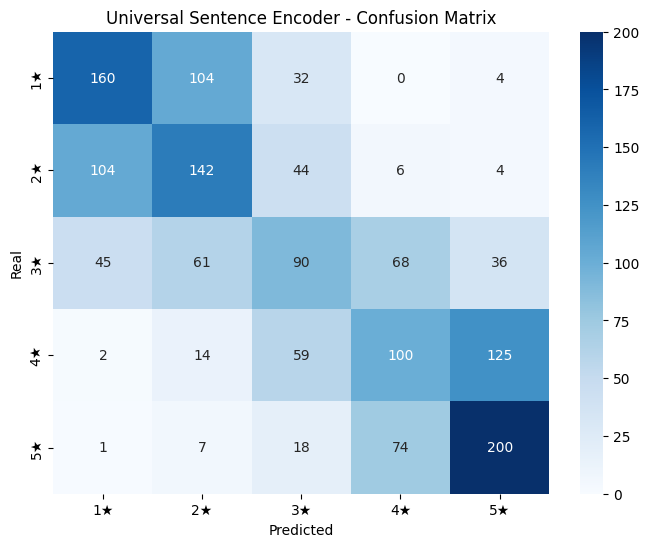


Test prediction :
Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment
Predicted : 4


In [ ]:
print("Loading Universal Sentence Encoder...")
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

df = pd.read_excel("data/reviews_nlp.xlsx")
df = df[df["type"] == "train"].reset_index(drop=True)
df = df[['avis_cor','note']]
df = df.dropna()
df['note'] = df['note'].astype(int)
X = df['avis_cor']
y = df['note']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# EMBEDDINGS
print("Encoding sentences with USE...")
X_train_embed = use_model(X_train.tolist()).numpy()
X_test_embed = use_model(X_test.tolist()).numpy()

# MODEL
model = LogisticRegression(
    max_iter=5000,
    #class_weight="balanced",
    random_state=42
)
model.fit(X_train_embed, y_train)
y_pred = model.predict(X_test_embed)

# ── USE + LogReg ──
acc_use  = accuracy_score(y_test, y_pred)
mae_use  = mean_absolute_error(y_test, y_pred)
rmse_use = np.sqrt(mean_squared_error(y_test, y_pred))
f1_use   = f1_score(y_test, y_pred, average="macro")
print("Accuracy :", acc_use)
print("MAE :", mae_use)
print("RMSE :", rmse_use)
print("F1 Macro :", f1_use)
print("\nClassification report\n")
print(classification_report(y_test, y_pred))

# CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = sorted(list(set(y_true)))
    labels_star = [f"{i}★" for i in labels]
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels_star,
        yticklabels=labels_star
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.show()

plot_confusion_matrix(
    y_test,
    y_pred,
    "Universal Sentence Encoder - Confusion Matrix"
)

# TEST REVIEW
def predict_review(review):
    emb = use_model([review]).numpy()
    return model.predict(emb)[0]

print("\nTest prediction :")
test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
#"very courteous customer service site a little difficult to use  very courteous customer service site a little difficult to use  very courteous customer service site a little difficult to use"
print(test)
print("Predicted :", predict_review(test))

## 10) Basic model with an embedding layer

Nous mettons en place un modèle de classification basé sur des embeddings de phrases (USE) combinés à un réseau de neurones dense.

Les avis sont d’abord encodés avec le Universal Sentence Encoder, ce qui permet d’obtenir une représentation vectorielle de chaque texte capturant son sens global. Ces embeddings sont ensuite utilisés comme entrée d’un modèle de type réseau de neurones (architecture fully connected), composé de plusieurs couches denses avec activation ReLU et régularisation par dropout.

Le modèle est entraîné pour prédire la note (1 à 5 étoiles) avec une sortie en softmax, en utilisant une fonction de perte adaptée à la classification multi-classes. Un mécanisme d’early stopping est utilisé afin d’éviter le surapprentissage et de conserver les meilleurs poids.

Loading Universal Sentence Encoder...
Encoding sentences with USE...

Entraînement des modèles configuré avec Early Stopping (Patience = 10, Epochs = 100).
Epoch 1/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4060 - loss: 1.2661 - val_accuracy: 0.4215 - val_loss: 1.1956
Epoch 2/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.4527 - loss: 1.1557 - val_accuracy: 0.4326 - val_loss: 1.1830
Epoch 3/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.4700 - loss: 1.1341 - val_accuracy: 0.4407 - val_loss: 1.1815
Epoch 4/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - accuracy: 0.4748 - loss: 1.1192 - val_accuracy: 0.4348 - val_loss: 1.1831
Epoch 5/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.4917 - loss: 1.1028 - val_accuracy: 0.4407 - val_loss: 1.1824
Epoch 6/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.4987 - loss: 1.0886 - val_accuracy: 0.4430 - val_loss: 1.1852
Epoch 7/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - acc

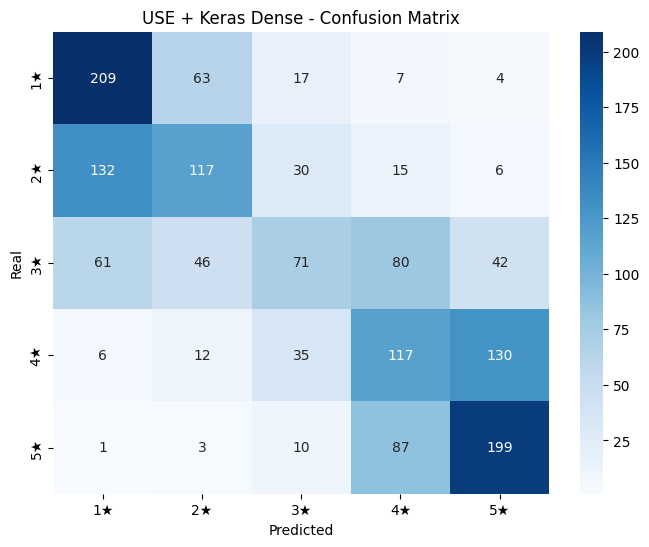


Test prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted : 4


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- LOAD DATA ---
df = pd.read_excel("data/reviews_nlp.xlsx")
df = df[['avis_cor','note']].dropna()
df['note'] = df['note'].astype(int)

X = df['avis_cor']
y = df['note']

# --- SHIFT LABELS FOR KERAS (0-indexed) ---
y_shifted = y - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y_shifted, test_size=0.1, random_state=42, stratify=y_shifted
)

# --- LOAD USE MODEL ---
print("Loading Universal Sentence Encoder...")
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

# --- EMBEDDINGS ---
print("Encoding sentences with USE...")
X_train_embed = use_model(X_train.tolist()).numpy()
X_test_embed = use_model(X_test.tolist()).numpy()

# --- BUILD KERAS MODEL ---
input_dim = X_train_embed.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(y.unique()), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- EARLY STOPPING ---
early_stopping = tf.keras.callbacks.EarlyStopping(
    #monitor='loss',
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\nEntraînement des modèles configuré avec Early Stopping (Patience = 10, Epochs = 100).")

# --- TRAIN ---
history = model.fit(
    X_train_embed, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

# --- EVALUATION ---
y_pred_probs = model.predict(X_test_embed)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- CONVERT BACK TO ORIGINAL LABELS ---
y_test_orig = y_test + 1
y_pred_orig = y_pred + 1

# --- METRICS ---
acc_use_keras  = accuracy_score(y_test_orig, y_pred_orig)
mae_use_keras  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_use_keras = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
f1_use_keras   = f1_score(y_test_orig, y_pred_orig, average="macro")

print("Accuracy :", acc_use_keras)
print("MAE :", mae_use_keras)
print("RMSE :", rmse_use_keras)
print("F1 Macro :", f1_use_keras)

print("\nClassification report\n")
print(classification_report(y_test_orig, y_pred_orig))

# --- CONFUSION MATRIX ---
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    labels_star = [f"{i}★" for i in sorted(y_true.unique())]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_star,
                yticklabels=labels_star)
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.show()

plot_confusion_matrix(y_test_orig, y_pred_orig, "USE + Keras Dense - Confusion Matrix")

# --- TEST REVIEW ---
def predict_review(review):
    emb = use_model([review]).numpy()
    pred_probs = model.predict(emb)
    return np.argmax(pred_probs, axis=1)[0] + 1

test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"

print("\nTest prediction:")
print("Predicted :", predict_review(test))

## 11) LLM (Ollama) + Logistic Regression + Embeddings

Nous combinons des embeddings issus d’un LLM (Ollama / Mistral) avec un modèle de régression logistique pour prédire la note des avis clients.

Les avis sont encodés sous forme de vecteurs à l’aide d’un modèle d’embedding via Ollama. Ces représentations capturent davantage de contexte que des approches classiques, en tenant compte de combinaisons de mots et non uniquement de mots isolés. Les embeddings sont ensuite utilisés pour entraîner un classifieur de type régression logistique.

En complément, une approche basée sur le prompt engineering est utilisée avec un LLM (Mistral) afin de prédire directement la note à partir du texte, en s’appuyant sur des exemples (few-shot learning) et en demandant explicitement une justification via des mots-clés.

Enfin, une approche hybride combine les prédictions issues des embeddings et celles du LLM, en pondérant les deux résultats pour obtenir une prédiction finale plus robuste. Cette méthode permet de tirer parti à la fois de la représentation vectorielle et de la capacité du LLM à interpréter le contexte sémantique des avis.

Generating embeddings for training data...

RESULTS - Logistic Regression on Ollama Embeddings
Accuracy : 0.4686666666666667
MAE : 0.6806666666666666
RMSE : 1.011599393699568
F1 Macro : 0.4583340249597173

Classification Report

              precision    recall  f1-score   support

           1       0.53      0.63      0.57       300
           2       0.44      0.45      0.44       300
           3       0.34      0.24      0.28       300
           4       0.44      0.38      0.41       300
           5       0.53      0.64      0.58       300

    accuracy                           0.47      1500
   macro avg       0.46      0.47      0.46      1500
weighted avg       0.46      0.47      0.46      1500



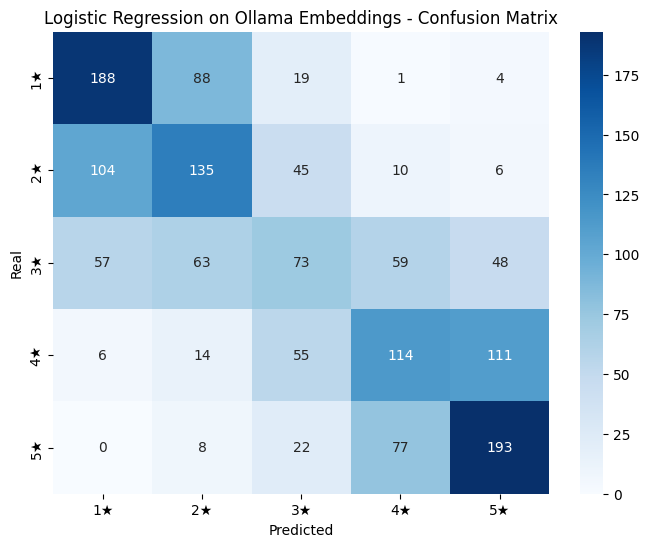


Test Review :
Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment

Predicted stars (LLM) : 4
Important keywords    : price, fast, temp, other housing, other car contracts, better

── Top 10 words per star rating ──
  1★ : poor service, long wait, unhelpful, expensive, bad experience, not recommended
  2★ : slow response, confusing process, difficult to understand, unsatisfied, disappointed
  3★ : average service, reasonable price, easy process, some issues, could be better
  4★ : good service, fast response, clear process, satisfied, positive experience
  5★ : excellent service, quick response, easy process, highly recommended, outstanding

Predicted stars (Hybrid) : 5
Important keywords       : price, fast, temp, other housing, other car contracts, better

── Top 10 words per star rating (Hybrid) ──
  1★ : poor service, long wait, unhelpful, expensive, bad exper

In [3]:
df = pd.read_excel("data/reviews_nlp.xlsx")
df = df[['avis_cor','note']].dropna()
df['note'] = df['note'].astype(int)
X = df['avis_cor']
y = df['note']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# BATCHED + TRUNCATED EMBEDDINGS
def get_embeddings_batched(texts, model="all-minilm", batch_size=16, max_length=200):
    """
    Generate embeddings in batches and truncate texts to max_length words
    to avoid context overflow errors.
    """
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Truncate each review to max_length words
        batch_trunc = [" ".join(text.split()[:max_length]) for text in batch]
        response = ollama.embed(model=model, input=batch_trunc)
        embeddings.extend(response.embeddings)
    return np.array(embeddings)

# GENERATE EMBEDDINGS
print("Generating embeddings for training data...")
X_train_emb = get_embeddings_batched(X_train.tolist(), batch_size=16)
X_test_emb = get_embeddings_batched(X_test.tolist(), batch_size=16)

# LOGISTIC REGRESSION MODEL
clf = LogisticRegression(max_iter=500, random_state=42, class_weight="balanced")
clf.fit(X_train_emb, y_train)
y_pred_emb = clf.predict(X_test_emb)


# ── Ollama + LogReg ──
acc_ollama  = accuracy_score(y_test, y_pred_emb)
mae_ollama  = mean_absolute_error(y_test, y_pred_emb)
rmse_ollama = np.sqrt(mean_squared_error(y_test, y_pred_emb))
f1_ollama   = f1_score(y_test, y_pred_emb, average="macro")
print("\nRESULTS - Logistic Regression on Ollama Embeddings")
print("Accuracy :", acc_ollama)
print("MAE :", mae_ollama)
print("RMSE :", rmse_ollama)
print("F1 Macro :", f1_ollama)
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_emb))

# CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = sorted(list(set(y_true)))
    labels_star = [f"{i}★" for i in labels]

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_star, yticklabels=labels_star)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.show()

plot_confusion_matrix(y_test, y_pred_emb, "Logistic Regression on Ollama Embeddings - Confusion Matrix")

# FEW-SHOT EXAMPLES FOR LLM
examples = pd.concat([
    df[df['note']==1].sample(50, random_state=42),
    df[df['note']==2].sample(50, random_state=42),
    df[df['note']==3].sample(50, random_state=42),
    df[df['note']==4].sample(50, random_state=42),
    df[df['note']==5].sample(50, random_state=42)
])
example_text = ""
for _, row in examples.iterrows():
    example_text += f"Review: {row['avis_cor']}\nStars: {row['note']}\n\n"

# HELPER FUNCTION: EXTRACT RATING
def extract_rating(text):
    match = re.search(r"[1-5]", text)
    if match:
        return int(match.group())
    return 3

def predict_review_llm(review):
    prompt = f"""
You are a sentiment analysis model.

Predict the number of stars (1 to 5) from a customer review.

Follow these instructions:
- 1 = very negative
- 2 = negative
- 3 = neutral
- 4 = positive
- 5 = very positive

Few-shot examples:
{example_text}

Review to analyze: {review}

Think step by step about the sentiment, then answer ONLY in the following format, nothing else:

STARS: <number between 1 and 5>
KEYWORDS: <comma-separated list of words from the review that justify the rating>
TOP_WORDS_1: <10 most important words/expressions that generally indicate a 1-star review>
TOP_WORDS_2: <10 most important words/expressions that generally indicate a 2-star review>
TOP_WORDS_3: <10 most important words/expressions that generally indicate a 3-star review>
TOP_WORDS_4: <10 most important words/expressions that generally indicate a 4-star review>
TOP_WORDS_5: <10 most important words/expressions that generally indicate a 5-star review>
"""
    response = ollama.chat(
        model="mistral",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )
    answer = response['message']['content'].strip()
    return answer


def extract_rating_and_keywords(text):
    """Extract rating, review keywords, and top 10 words per star rating."""
    rating = 3
    keywords = []
    top_words = {}

    stars_match = re.search(r"STARS:\s*([1-5])", text)
    if stars_match:
        rating = int(stars_match.group(1))

    keywords_match = re.search(r"KEYWORDS:\s*(.+)", text)
    if keywords_match:
        keywords = [kw.strip() for kw in keywords_match.group(1).split(",")]

    for star in range(1, 6):
        pattern = rf"TOP_WORDS_{star}:\s*(.+)"
        match = re.search(pattern, text)
        if match:
            top_words[star] = [w.strip() for w in match.group(1).split(",")]

    return rating, keywords, top_words


# TEST REVIEW LLM
test_review = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"

print("\nTest Review :")
print(test_review)

raw_answer = predict_review_llm(test_review)
pred_stars, important_words, top_words_per_star = extract_rating_and_keywords(raw_answer)

print(f"\nPredicted stars (LLM) : {pred_stars}")
print(f"Important keywords    : {', '.join(important_words)}")
print("\n── Top 10 words per star rating ──")
for star, words in top_words_per_star.items():
    print(f"  {star}★ : {', '.join(words)}")


# HYBRID PREDICTION FUNCTION
def hybrid_prediction(review, emb_weight=0.6, llm_weight=0.4):
    emb = get_embeddings_batched([review], batch_size=1)
    pred_emb = clf.predict(emb)[0]

    raw_answer = predict_review_llm(review)
    pred_llm, keywords, top_words_per_star = extract_rating_and_keywords(raw_answer)

    final_pred = round(emb_weight * pred_emb + llm_weight * pred_llm)
    return final_pred, keywords, top_words_per_star


hybrid_stars, hybrid_keywords, hybrid_top_words = hybrid_prediction(test_review)
print(f"\nPredicted stars (Hybrid) : {hybrid_stars}")
print(f"Important keywords       : {', '.join(hybrid_keywords)}")
print("\n── Top 10 words per star rating (Hybrid) ──")
for star, words in hybrid_top_words.items():
    print(f"  {star}★ : {', '.join(words)}")

## 12) BERT + LoRA

#### Sentiment Analysis Prediction

Nous réalisons une tâche de sentiment analysis en utilisant un modèle de type BERT (DistilBERT) fine-tuné avec LoRA.

Les avis sont d’abord filtrés pour ne conserver que trois classes de sentiment (négatif, neutre, positif), obtenues à partir des notes : la note 1 est associée au négatif, la note 3 au neutre, et la note 5 au positif. Cette simplification permet d’obtenir une séparation plus claire entre les classes.

Le modèle DistilBERT est ensuite utilisé comme base, auquel on applique une adaptation LoRA (Low-Rank Adaptation) afin de fine-tuner le modèle de manière efficace en ne modifiant qu’un nombre réduit de paramètres. Les textes sont tokenisés puis utilisés pour entraîner le modèle sur la tâche de classification.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8772.13it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.934967
100,0.771475
150,0.718339
200,0.647257
250,0.663792
300,0.687840
350,0.679116
400,0.677416
450,0.648609
500,0.625031



Classification Report:

              precision    recall  f1-score   support

    negative       0.75      0.90      0.82       300
     neutral       0.69      0.44      0.54       300
    positive       0.76      0.87      0.81       300

    accuracy                           0.74       900
   macro avg       0.73      0.74      0.72       900
weighted avg       0.73      0.74      0.72       900



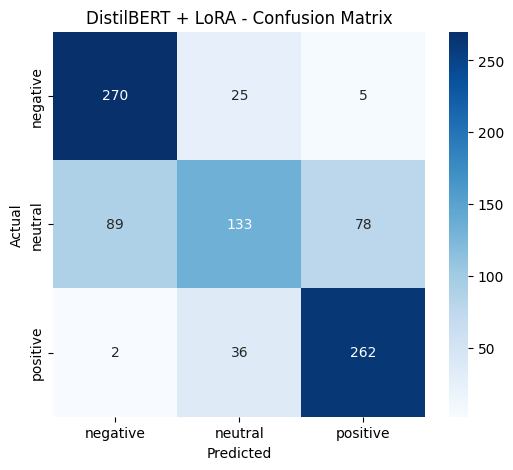


Test review prediction:

Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment
Predicted sentiment : positive


In [ ]:
# BERT + LoRA
df = pd.read_excel("data/reviews_sen.xlsx")
df = df[['avis_cor', 'note']].dropna()

# Map notes to sentiment
def map_sentiment(note):
    if note in [1,2]:
        return 0
    elif note == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['note'].apply(map_sentiment)
X = df['avis_cor'].tolist()
y = df['sentiment'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# TOKENIZER
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
max_length = 128
train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=max_length
)
test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=max_length
)

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)

# MODEL + LORA
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_lin","v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)
model = get_peft_model(model, lora_config)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1": f1}

# TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./model/distilbert_lora_sentiment",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=3e-4,
    num_train_epochs=2,
    logging_steps=50,
    fp16=True,
    save_total_limit=2
)

# TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
preds = trainer.predict(test_dataset)
pred_labels = np.argmax(preds.predictions, axis=1)
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    pred_labels,
    target_names=["negative","neutral","positive"]
))

cm = confusion_matrix(y_test, pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative","neutral","positive"],
    yticklabels=["negative","neutral","positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT + LoRA - Confusion Matrix")
plt.show()

# TEST REVIEW
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
labels = ["negative","neutral","positive"]
def predict_review(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k,v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()
    return labels[pred]

# SAVE MODEL
model.save_pretrained("./model/distilbert_lora_sentiment")
tokenizer.save_pretrained("./model/distilbert_lora_sentiment")

# TEST REVIEW
print("\nTest review prediction:\n")
test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
print(test)
print("Predicted sentiment :", predict_review(test))

#### Using saved model

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9919.13it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Classification Report:

              precision    recall  f1-score   support

    negative       0.75      0.90      0.82       300
     neutral       0.69      0.44      0.54       300
    positive       0.76      0.87      0.81       300

    accuracy                           0.74       900
   macro avg       0.73      0.74      0.72       900
weighted avg       0.73      0.74      0.72       900



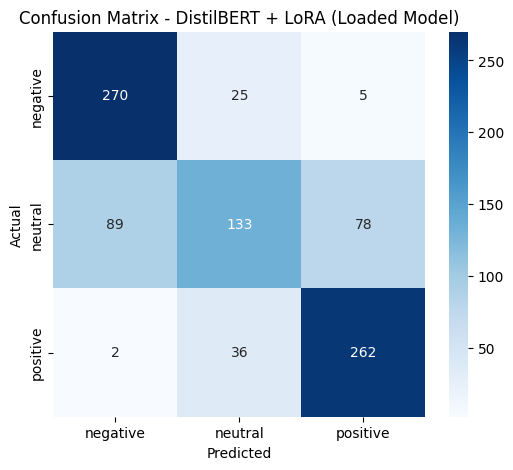


Test review prediction:

Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment
Predicted sentiment : positive


In [ ]:
# BERT + LoRA 
df = pd.read_excel("data/reviews_sen.xlsx")
df = df[['avis_cor','note']].dropna()

# MAP SENTIMENT
def map_sentiment(note):
    if note in [1,2]:
        return 0
    elif note == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['note'].apply(map_sentiment)
X = df['avis_cor'].tolist()
y = df['sentiment'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# LOAD MODEL
model_path = "./model/distilbert_lora_sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_path)
base_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)
model = PeftModel.from_pretrained(base_model, model_path)

# fusion LoRA to speed up
model = model.merge_and_unload()


# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
max_length = 128
labels = ["negative","neutral","positive"]

def predict_review(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k,v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()
    return pred

# PREDICTIONS
preds = []
for text in X_test:
    pred = predict_review(text)
    preds.append(pred)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    preds,
    target_names=labels
))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT + LoRA (Loaded Model)")
plt.show()

# TEST REVIEW
print("\nTest review prediction:\n")
test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
print(test)
pred = predict_review(test)
print("Predicted sentiment :", labels[pred])

## 13) TF-IDF + XGBOOST

Avec TF-IDF et XGBoost, nous avons réalisé une analyse de sentiments. Nous avons considéré les avis notés 1 comme négatifs, 3 comme neutres et 5 comme positifs. Nous avons décidé de retirer complètement les avis notés 2 et 4, car le modèle avait du mal à les classer correctement. Nous nous sommes demandé s’il fallait les considérer comme positifs ou négatifs, ou bien les inclure dans la classe neutre. Finalement, nous avons choisi de les supprimer car ils ne sont ni totalement négatifs ni totalement positifs.

Dans l’implémentation, les textes sont vectorisés avec TF-IDF en utilisant des unigrammes et bigrammes, puis un modèle XGBoost est entraîné pour effectuer une classification multi-classes (négatif, neutre, positif). Le modèle apprend à partir des représentations TF-IDF afin de capturer les patterns lexicaux associés à chaque sentiment.

En complément, une analyse des mots les plus représentatifs de chaque classe est réalisée en calculant la moyenne des scores TF-IDF par classe. Pour chaque avis, il est également possible d’identifier les mots les plus contributifs à la prédiction en combinant les poids TF-IDF avec les importances des features du modèle XGBoost.

Les résultats montrent que le modèle capte des tendances lexicales cohérentes pour chaque classe de sentiment.
- Pour la classe négative, on observe une forte présence de mots de négation comme not, no, ainsi que des mots fonctionnels fréquents (in, that, my, etc.). Cela reflète le fait que les avis négatifs contiennent souvent des formulations avec des négations et des structures plus variées.
- Pour la classe neutre, le vocabulaire reste proche du langage général, avec encore des mots peu discriminants (for, my, is, with). On remarque cependant la présence de termes comme insurance, ce qui suggère que ces avis sont descriptifs sans orientation émotionnelle forte.
- Pour la classe positive, les mots les plus caractéristiques sont clairement orientés sentiment positif, avec very, satisfied, recommend, service, price. La présence de bigrammes comme satisfied with confirme des expressions typiques d’avis positifs.

Sur l’exemple de test, la prédiction est positive, ce qui est cohérent avec le contenu de l’avis qui contient des expressions comme satisfied et fast. Les mots les plus contributifs à la décision incluent justement satisfied, fast et price, ce qui montre que le modèle s’appuie sur des termes fortement corrélés au sentiment positif.

Globalement, les résultats montrent que le modèle repose principalement sur des signaux lexicaux simples mais efficaces, avec une bonne séparation entre expressions négatives et positives, tandis que la classe neutre reste plus difficile à caractériser car moins marquée lexicalement.

Accuracy : 0.7222222222222222
MAE      : 0.2922222222222222
RMSE     : 0.5666666666666667
F1 Macro : 0.7157043492520595

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.85      0.78       300
     neutral       0.63      0.51      0.57       300
    positive       0.81      0.80      0.80       300

    accuracy                           0.72       900
   macro avg       0.72      0.72      0.72       900
weighted avg       0.72      0.72      0.72       900



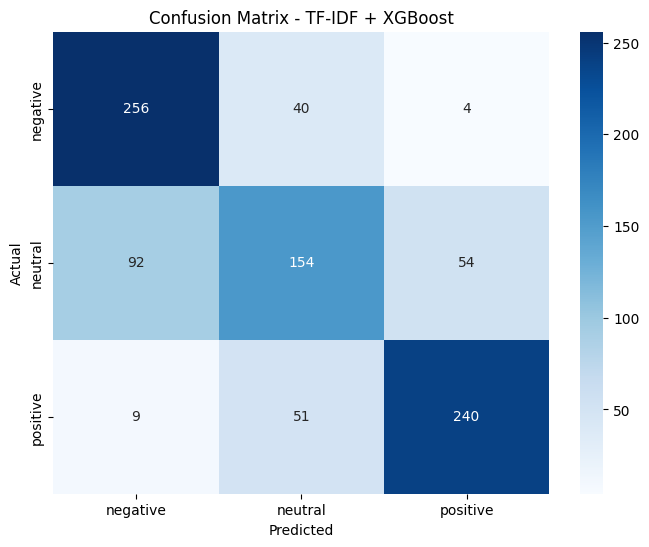


Computing top words per sentiment class...

Top 10 words — NEGATIVE
----------------------------------------
  not                       : 0.0501
  in                        : 0.0432
  that                      : 0.0420
  my                        : 0.0416
  for                       : 0.0416
  is                        : 0.0370
  it                        : 0.0346
  have                      : 0.0345
  you                       : 0.0331
  no                        : 0.0326

Top 10 words — NEUTRAL
----------------------------------------
  for                       : 0.0344
  my                        : 0.0342
  is                        : 0.0334
  not                       : 0.0319
  in                        : 0.0317
  with                      : 0.0287
  it                        : 0.0274
  that                      : 0.0268
  have                      : 0.0265
  insurance                 : 0.0251

Top 10 words — POSITIVE
----------------------------------------
  very             

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error,
                             accuracy_score, f1_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_excel("data/reviews_sen.xlsx")
df = df[['avis_cor', 'note']].dropna()

# MAP SENTIMENT
def map_sentiment(note):
    if note in [1, 2]:
        return 0
    elif note == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['note'].apply(map_sentiment)
X = df['avis_cor']
y = df['sentiment']

# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# ── TF-IDF ────────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    max_df=0.5,
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ── XGBOOST MODEL ─────────────────────────────────────────────────────────────
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_tfidf, y_train)

# ── PREDICTION ────────────────────────────────────────────────────────────────
y_pred = xgb_model.predict(X_test_tfidf)

# ── EVALUATION ────────────────────────────────────────────────────────────────
mae      = mean_absolute_error(y_test, y_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy :", accuracy)
print("MAE      :", mae)
print("RMSE     :", rmse)
print("F1 Macro :", f1_macro)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TF-IDF + XGBoost")
plt.show()

# ── TOP 10 WORDS PER SENTIMENT CLASS via TF-IDF mean ─────────────────────────
def get_top_words_per_class(X_train, y_train, tfidf, labels, n_words=10):
    """
    For each sentiment class, compute the average TF-IDF score per feature
    and return the top n_words most characteristic words with their scores.
    """
    feature_names = tfidf.get_feature_names_out()
    top_words = {}
    for class_idx, class_name in enumerate(labels):
        mask = y_train.values == class_idx
        class_tfidf = tfidf.transform(X_train[mask])
        avg_tfidf = np.array(class_tfidf.mean(axis=0)).flatten()
        top_indices = avg_tfidf.argsort()[-n_words:][::-1]
        top_words[class_name] = [
            (feature_names[i], avg_tfidf[i]) for i in top_indices
        ]
    return top_words

# ── IMPORTANT WORDS FOR A SPECIFIC REVIEW ─────────────────────────────────────
def get_important_words_for_review(review, tfidf, xgb_model, n_words=10):
    """
    For a specific review, multiply its TF-IDF vector by XGBoost global
    feature importances to identify the words that contributed most
    to the prediction, with their scores.
    """
    feature_names       = tfidf.get_feature_names_out()
    feature_importances = xgb_model.feature_importances_

    vec          = tfidf.transform([review])
    tfidf_scores = np.array(vec.todense()).flatten()

    # Combined score = TF-IDF weight × XGBoost feature importance
    combined_scores = tfidf_scores * feature_importances

    top_indices = combined_scores.argsort()[-n_words:][::-1]
    important_words = [
        (feature_names[i], combined_scores[i])
        for i in top_indices if combined_scores[i] > 0
    ]
    return important_words

# ── DISPLAY HELPER ────────────────────────────────────────────────────────────
def print_top_words(words_with_scores, title):
    print(f"\n{title}")
    print("-" * 40)
    for word, score in words_with_scores:
        print(f"  {word:<25} : {score:.4f}")

# ── TOP 10 WORDS PER CLASS ────────────────────────────────────────────────────
labels = ["negative", "neutral", "positive"]
print("\nComputing top words per sentiment class...")
top_words_per_class = get_top_words_per_class(X_train, y_train, tfidf, labels)

for class_name, words_with_scores in top_words_per_class.items():
    print_top_words(words_with_scores, f"Top 10 words — {class_name.upper()}")

# ── TEST REVIEW ───────────────────────────────────────────────────────────────
def predict_review(review):
    vec  = tfidf.transform([review])
    pred = xgb_model.predict(vec)[0]
    return labels[pred]

print("\n" + "=" * 40)
print("TEST REVIEW")
print("=" * 40)
test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
print(test)

predicted_sentiment = predict_review(test)
important_words     = get_important_words_for_review(test, tfidf, xgb_model)

print(f"\nPredicted sentiment : {predicted_sentiment}")
print_top_words(
    important_words if important_words else [],
    "Top contributing words"
)
if not important_words:
    print("  (none found in vocabulary)")

## 14) LSTM (Long Short-Term Memory)

Nous utilisons un modèle LSTM bidirectionnel, dont l’intérêt principal est de prendre en compte la séquence des mots et leur ordre dans le texte, contrairement aux approches TF-IDF ou aux modèles basés sur des embeddings statiques.

Les avis sont transformés en séquences de tokens puis vectorisés via une couche d’embedding apprise, directement optimisée pendant l’entraînement. Le modèle LSTM permet de capturer les dépendances à long terme dans les phrases, tandis que la version bidirectionnelle exploite à la fois le contexte passé et futur d’un mot dans la phrase.

Une différence clé par rapport aux méthodes précédentes est que le modèle apprend conjointement les représentations des mots et la tâche de classification, sans dépendre d’une vectorisation externe comme TF-IDF ou USE. Cela lui permet de mieux modéliser la structure séquentielle du langage.

Enfin, des class weights sont utilisés pour compenser les déséquilibres entre classes, et le modèle est entraîné avec une sortie en softmax pour prédire le sentiment (négatif, neutre, positif) à partir de la compréhension globale de la séquence.

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,092,931 (4.17 MB)

 Trainable params: 1,092,931 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.6186 - loss: 0.8005 - val_accuracy: 0.6704 - val_loss: 0.7074
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.7278 - loss: 0.6140 - val_accuracy: 0.6790 - val_loss: 0.6794
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.7834 - loss: 0.5228 - val_accuracy: 0.6877 - val_loss: 0.7120
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.8195 - loss: 0.4574 - val_accuracy: 0.6778 - val_loss: 0.7540
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.8444 - loss: 0.4019 - val_accuracy: 0.6679 - val_loss: 0.8274
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

Classification Report:

              precision    recall  f1-score   support

    negative       0.74      0.74      0.74       300
     neutral       0.55      0.54      0.55       300
    positive       0.78      0.80      0.79       300

    accuracy                           0.69       900
   macro avg      

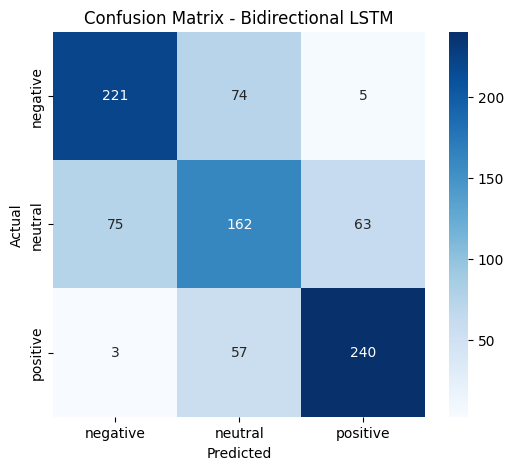


Test review prediction:
Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted sentiment: neutral


In [ ]:
df = pd.read_excel("data/reviews_sen.xlsx")
df = df[['avis_cor', 'note']].dropna()

# Map notes to 3 classes: negative / neutral / positive
def map_sentiment(note):
    if note == 1:
        return 0  # negative
    elif note in [2,3,4]:
        return 1  # neutral
    else:
        return 2  # positive
df['sentiment'] = df['note'].apply(map_sentiment)
X = df['avis_cor'].astype(str).tolist()
y = df['sentiment'].tolist()

# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# TOKENIZER + PADDING
max_vocab = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)

# CLASS WEIGHTS
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# MODEL: BIDIRECTIONAL LSTM
embedding_dim = 100
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=embedding_dim),  # input_length optionnel
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Force model building to display the correct summary
model.build(input_shape=(None, X_train_pad.shape[1]))
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# TRAIN
history = model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1
)

# PREDICTION
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# EVALUATION
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["negative","neutral","positive"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative","neutral","positive"],
            yticklabels=["negative","neutral","positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bidirectional LSTM")
plt.show()

# TEST REVIEW
def predict_review(review):
    seq = tokenizer.texts_to_sequences([review])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = np.argmax(model.predict(pad), axis=1)[0]
    return ["negative","neutral","positive"][pred]

# Exemple
test = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
print("\nTest review prediction:")
print(test)
print("Predicted sentiment:", predict_review(test))

## 15) Zero-shot classification + HuggingFace

####  Categories/Subjects Detection

Nous utilisons une approche de zero-shot classification via un modèle pré-entraîné (BART-MNLI) de HuggingFace pour attribuer automatiquement une catégorie à chaque avis, sans avoir besoin d’entraînement spécifique sur nos données.

Les avis sont classés parmi plusieurs catégories définies à l’avance : Pricing, Coverage, Enrollment, Customer Service, Claims Processing, Cancellation et Other. Le modèle compare le texte à chacune de ces catégories et sélectionne celle qui est la plus probable.

Les résultats montrent que le modèle parvient à associer des thèmes cohérents aux avis, par exemple :

des avis contenant des problématiques de résiliation sont classés en Cancellation
des retours liés à des problèmes de support ou d’interaction client sont classés en Customer Service
des avis mentionnant des garanties ou des sinistres sont classés en Coverage

Sur l’exemple de test, la catégorie prédite est Pricing, ce qui est cohérent avec le contenu de l’avis qui met en avant le prix et l’attractivité de l’offre.

Cette approche permet donc de classifier des textes sans annotation préalable, en s’appuyant uniquement sur des catégories définies et sur les capacités de compréhension sémantique du modèle.

In [ ]:
df = pd.read_excel("data/reviews_sub.xlsx")
df = df[['avis_cor']].dropna()

# ZERO-SHOT CLASSIFICATION PIPELINE
# Pre-trained model for NLI
model_name = "facebook/bart-large-mnli"

classifier = pipeline(
    "zero-shot-classification",
    model=model_name,
    device=0
)

# DEFINE CATEGORIES
categories = [
    "Pricing",
    "Coverage",
    "Enrollment",
    "Customer Service",
    "Claims Processing",
    "Cancellation",
    "Other"
]

# APPLY CLASSIFICATION
def predict_category(text):
    result = classifier(
        text,
        candidate_labels=categories,
        multi_label=False
    )
    # Most probable category
    return result['labels'][0]
df['category'] = df['avis_cor'].apply(predict_category)
print(df[['avis_cor', 'category']].head(10))

# SAVE MODEL LOCALLY
#save_path = "./zero_shot_model"
#classifier.model.save_pretrained(save_path)
#classifier.tokenizer.save_pretrained(save_path)
df.to_excel("data/reviews_cat.xlsx", index=False)

# TEST REVIEW
test_review = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
predicted_category = predict_category(test_review)
print("\nTest review:", test_review)
print("Predicted category:", predicted_category)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 5538.31it/s]


                                            avis_cor          category
0  direct insurance it's really a disaster no fol...  Customer Service
1  flee this insurance    it is stipulated in my ...      Cancellation
2  daily telephone harassment on the part of this...          Coverage
3  hello one of my solar collectors has been dama...          Coverage
4  never had an accident    years that i have the...           Pricing
5  after having succumbed to the attractive offer...  Customer Service
6  in the past my partner has already been a clie...  Customer Service
7  d consillee     termination of contracts under...      Cancellation
8  the recidivist driver is disabled defect in th...      Cancellation
9  insurance to flee breaks of ice taken into acc...          Coverage

Test review: Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment
Predicted category: Pricing


In [ ]:
from transformers import pipeline

# ZERO-SHOT CLASSIFICATION PIPELINE
model_name = "facebook/bart-large-mnli"

classifier = pipeline(
    "zero-shot-classification",
    model=model_name,
    device=0  # ou -1 si tu veux utiliser le CPU
)

# DEFINE CATEGORIES
categories = [
    "Pricing",
    "Coverage",
    "Enrollment",
    "Customer Service",
    "Claims Processing",
    "Cancellation",
    "Other"
]

# FUNCTION TO PREDICT CATEGORY
def predict_category(text):
    result = classifier(
        text,
        candidate_labels=categories,
        multi_label=False
    )
    return result['labels'][0]

# TEST SINGLE REVIEW
single_review = "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment"
predicted_category = predict_category(single_review)

print("Review:", single_review)
print("Predicted category:", predicted_category)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 9583.56it/s]


Review: Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment
Predicted category: Pricing


## 16)  Comparison of different models

#### Star Prediction

Les résultats montrent une hiérarchie assez claire entre les approches testées, avec un modèle qui se démarque légèrement des autres.

Le meilleur modèle est TF-IDF + Logistic Regression, qui obtient :
- la meilleure accuracy (~0.51)
- le meilleur F1-score macro (~0.50)
- la plus faible MAE (~0.61)

Cela indique que ce modèle est le plus stable globalement pour prédire les notes, même si les performances restent modestes (proche du hasard sur 5 classes).

Comparaison globale :

### TF-IDF + LogReg
- Le plus performant sur tous les indicateurs
- Cohérent avec le fait que TF-IDF capture bien les mots discriminants + un modèle linéaire simple suffit souvent pour ce type de tâche

### Ollama Embeddings + LogReg
- Performances légèrement inférieures
- Les embeddings capturent mieux le contexte sémantique, mais la classification linéaire derrière ne semble pas exploiter pleinement cette richesse

### USE + LogReg / USE + Keras Dense
- Résultats plus faibles
- Possiblement dus à un dataset limité ou à un manque d’adaptation fine du modèle (pas de fine-tuning profond)

Points à retenir :
- Les méthodes classiques (TF-IDF + modèle simple) restent très compétitives sur ce type de dataset
- Les embeddings modernes apportent plus de sémantique, mais nécessitent souvent plus de données ou des modèles plus complexes pour surpasser TF-IDF
- Les performances globales suggèrent que la tâche de prédiction de notes est difficile (chevauchement entre classes, subjectivité des avis)

       COMPARISON — NUMBER OF STARS PREDICTION
                        Model  Accuracy       MAE      RMSE  F1 Macro
1             TF-IDF + LogReg  0.508667  0.610000  0.937728  0.503901
2  Ollama Embeddings + LogReg  0.491333  0.649333  0.983870  0.485405
3           USE + Keras Dense  0.475333  0.668667  1.002996  0.459873
4                USE + LogReg  0.461333  0.666667  0.979796  0.453894

Best model : TF-IDF + LogReg
  Accuracy : 0.5087
  F1 Macro : 0.5039
  MAE      : 0.6100


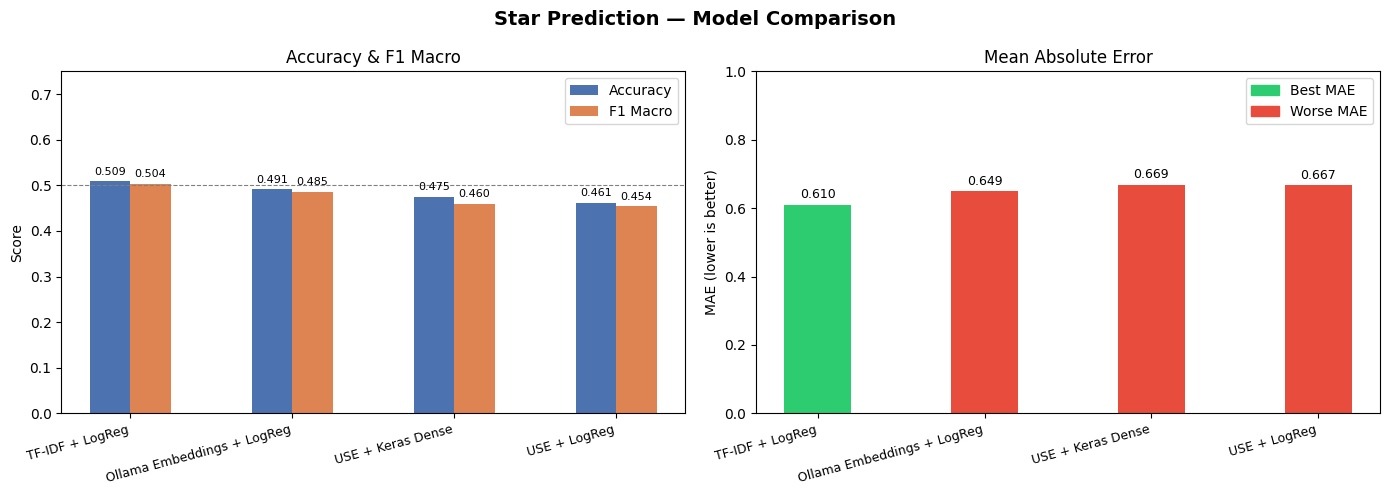


── Analysis ──
• Best accuracy : TF-IDF + LogReg (0.509)
• Best F1 Macro : TF-IDF + LogReg (0.504)
• Best MAE      : TF-IDF + LogReg (0.610)


In [ ]:
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# COMPARISON — récupère les variables déjà calculées
# ─────────────────────────────────────────────
results = {
    "TF-IDF + LogReg":           {"accuracy": acc_tfidf,     "mae": mae_tfidf,     "rmse": rmse_tfidf,     "f1": f1_tfidf},
    "USE + LogReg":              {"accuracy": acc_use,       "mae": mae_use,       "rmse": rmse_use,       "f1": f1_use},
    "Ollama Embeddings + LogReg":{"accuracy": acc_ollama,    "mae": mae_ollama,    "rmse": rmse_ollama,    "f1": f1_ollama},
    "USE + Keras Dense":         {"accuracy": acc_use_keras, "mae": mae_use_keras, "rmse": rmse_use_keras, "f1": f1_use_keras},
}

# ─────────────────────────────────────────────
# TABLEAU
# ─────────────────────────────────────────────
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ["Model", "Accuracy", "MAE", "RMSE", "F1 Macro"]
df_results = df_results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_results.index += 1

print("=" * 65)
print("       COMPARISON — NUMBER OF STARS PREDICTION")
print("=" * 65)
print(df_results.to_string())
print("=" * 65)

best = df_results.iloc[0]
print(f"\nBest model : {best['Model']}")
print(f"  Accuracy : {best['Accuracy']:.4f}")
print(f"  F1 Macro : {best['F1 Macro']:.4f}")
print(f"  MAE      : {best['MAE']:.4f}")

# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────
models   = df_results["Model"].values
accuracy = df_results["Accuracy"].values
f1       = df_results["F1 Macro"].values
mae      = df_results["MAE"].values

x     = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Star Prediction — Model Comparison", fontsize=14, fontweight="bold")

# ── Accuracy & F1 ──
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, accuracy, width, label="Accuracy", color="#4C72B0")
bars2 = ax1.bar(x + width/2, f1,       width, label="F1 Macro",  color="#DD8452")
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=9, rotation=15, ha="right")
ax1.set_ylim(0, 0.75)
ax1.set_ylabel("Score")
ax1.set_title("Accuracy & F1 Macro")
ax1.legend()
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# ── MAE ──
ax2 = axes[1]
colors = ["#2ecc71" if v == min(mae) else "#e74c3c" for v in mae]
bars3  = ax2.bar(x, mae, width=0.4, color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9, rotation=15, ha="right")
ax2.set_ylim(0, 1.0)
ax2.set_ylabel("MAE (lower is better)")
ax2.set_title("Mean Absolute Error")
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax2.legend(handles=[
    mpatches.Patch(color="#2ecc71", label="Best MAE"),
    mpatches.Patch(color="#e74c3c", label="Worse MAE")
])

plt.tight_layout()
plt.savefig("image/model_comparison_stars.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# ANALYSE TEXTUELLE
# ─────────────────────────────────────────────
print("\n── Analysis ──")
print(f"• Best accuracy : {df_results.iloc[0]['Model']} ({df_results.iloc[0]['Accuracy']:.3f})")
print(f"• Best F1 Macro : {df_results.loc[df_results['F1 Macro'].idxmax(), 'Model']} ({df_results['F1 Macro'].max():.3f})")
print(f"• Best MAE      : {df_results.loc[df_results['MAE'].idxmin(), 'Model']} ({df_results['MAE'].min():.3f})")

## 17) Error analysis

L’analyse des erreurs met en évidence plusieurs tendances importantes sur le comportement du modèle.

On observe tout d’abord que le modèle a des difficultés sur les classes intermédiaires, en particulier les notes 2★, 3★ et 4★, avec un taux d’erreur plus élevé que pour les extrêmes (1★ et 5★). La classe 3★ est la plus difficile à prédire, ce qui s’explique par son caractère ambigu : le vocabulaire utilisé dans les avis neutres est souvent proche à la fois du positif et du négatif.

Les confusions les plus fréquentes confirment cette proximité entre classes voisines :
- 2★ → 1★ est la confusion la plus fréquente
- 4★ → 5★ et 1★ → 2★ sont également très présentes
- Globalement, le modèle confond surtout des notes adjacentes

Points clés :
- Environ 79% des erreurs sont des erreurs “adjacentes” (gap = 1)
- Les erreurs non adjacentes (ex : 1★ → 5★) restent minoritaires (~21%)
- Le modèle ne fait donc presque jamais d’erreurs “grossières”

Cela montre que, même si la précision globale est limitée, le modèle reste cohérent dans ses prédictions : il se trompe principalement d’un niveau proche de la vraie note.

Enfin, les extrêmes (1★ et 5★) sont mieux reconnues :
- Les avis très négatifs ou très positifs contiennent un vocabulaire plus distinct
- À l’inverse, les avis neutres ou modérément positifs/négatifs se chevauchent davantage, ce qui explique les confusions

Total errors : 737 / 1500 (49.1%)

EXAMPLES OF MISCLASSIFIED REVIEWS

  True: 4★  →  Predicted: 5★
  "friendliness  professionalism and availability of the person who made me subscribe by phone..."

  True: 2★  →  Predicted: 1★
  "neoliane are profiteers  they make money on people's backs  do not go to them or to terminate as soon as possible     fo..."

  True: 1★  →  Predicted: 2★
  "little story of a lambda insured          insured at the macif since january       i have never had the slightest claim ..."

  True: 3★  →  Predicted: 4★
  "fast and effective  important franchise  especially for ice breaks  to see over the duration the efficiency of the care ..."

  True: 4★  →  Predicted: 5★
  "satisfied with the service and the speed of taking into account the contract  the price remains reasonable with regard t..."

  True: 5★  →  Predicted: 4★
  "insurance is satisfactory in all respects  also in terms of prices  customer services quality  and insurance details  fi..."

  True: 4★ 

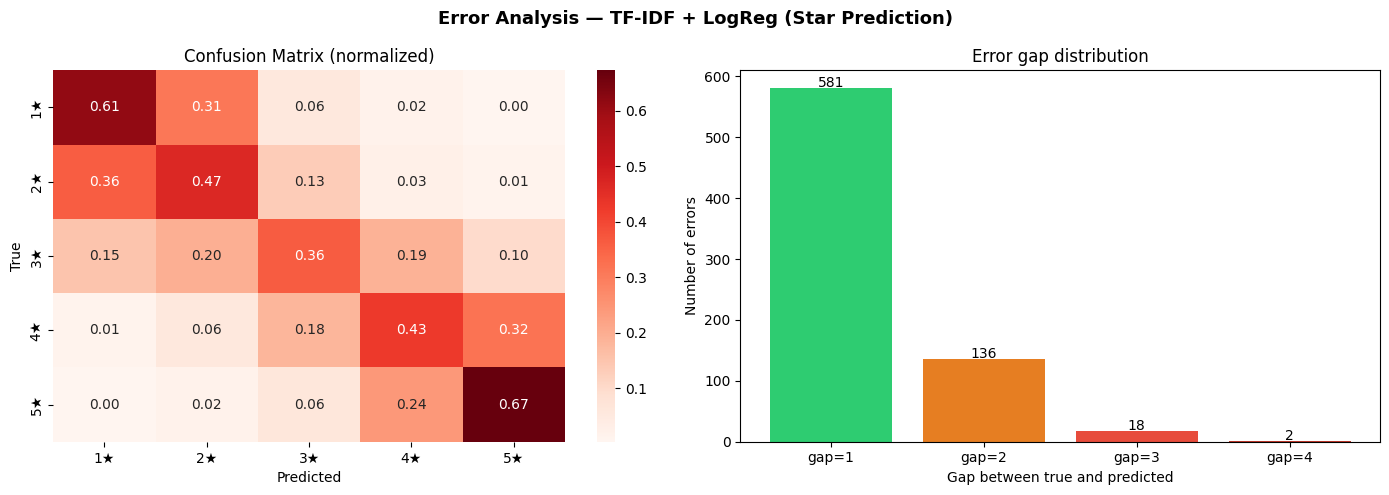


── Conclusion ──
• Most confused pair : 2★ → 1★ (108 cases)
• 79% of errors are adjacent (gap=1), meaning the model is
  'close' most of the time — it rarely confuses 1★ with 5★.
• Class 3★ (neutral) tends to have the highest error rate,
  as neutral reviews share vocabulary with both positive and negative ones.


In [ ]:
# ─────────────────────────────────────────────
# ERROR ANALYSIS — Best model : TF-IDF + LogReg
# ─────────────────────────────────────────────
from collections import Counter

# Reconstruction du dataframe de test avec les prédictions
df_errors = pd.DataFrame({
    "avis_cor":  X_test.values,
    "true":      y_test.values,
    "predicted": y_pred
})

errors = df_errors[df_errors["true"] != df_errors["predicted"]].copy()

print(f"Total errors : {len(errors)} / {len(df_errors)} ({len(errors)/len(df_errors)*100:.1f}%)\n")

# ── 1. Exemples mal classifiés ──
print("=" * 65)
print("EXAMPLES OF MISCLASSIFIED REVIEWS")
print("=" * 65)
for _, row in errors.head(8).iterrows():
    print(f"\n  True: {row['true']}★  →  Predicted: {row['predicted']}★")
    print(f"  \"{row['avis_cor'][:120]}...\"")

# ── 2. Paires de confusion les plus fréquentes ──
print("\n" + "=" * 65)
print("MOST FREQUENT CONFUSION PAIRS (true → predicted)")
print("=" * 65)
confusion_pairs = Counter(zip(errors["true"], errors["predicted"]))
print(f"\n  {'True → Predicted':<25} {'Count':>8} {'% of errors':>12}")
print(f"  {'─'*47}")
for (true, pred), count in confusion_pairs.most_common(10):
    pct = count / len(errors) * 100
    print(f"  {true}★ → {pred}★  {'▓' * int(pct/2):<20} {count:>5}   ({pct:.1f}%)")

# ── 3. Erreurs par classe (taux d'erreur) ──
print("\n" + "=" * 65)
print("ERROR RATE PER CLASS")
print("=" * 65)
print(f"\n  {'Class':<10} {'Total':>8} {'Errors':>8} {'Error rate':>12}")
print(f"  {'─'*40}")
for note in sorted(df_errors["true"].unique()):
    total  = (df_errors["true"] == note).sum()
    nerr   = ((df_errors["true"] == note) & (df_errors["true"] != df_errors["predicted"])).sum()
    rate   = nerr / total * 100
    bar    = "▓" * int(rate / 5)
    print(f"  {note}★        {total:>6}  {nerr:>8}     {rate:>6.1f}%  {bar}")

# ── 4. Analyse des erreurs adjacentes vs non-adjacentes ──
errors["gap"] = (errors["true"] - errors["predicted"]).abs()
adjacent     = (errors["gap"] == 1).sum()
non_adjacent = (errors["gap"] >  1).sum()
print(f"\n  Adjacent errors   (gap=1) : {adjacent}  ({adjacent/len(errors)*100:.1f}%)")
print(f"  Non-adjacent errors (gap>1) : {non_adjacent}  ({non_adjacent/len(errors)*100:.1f}%)")

# ── 5. Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error Analysis — TF-IDF + LogReg (Star Prediction)", fontsize=13, fontweight="bold")

# Heatmap des confusions normalisée
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(df_errors["true"], df_errors["predicted"], labels=[1,2,3,4,5])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels_star = ["1★","2★","3★","4★","5★"]

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=labels_star, yticklabels=labels_star, ax=axes[0])
axes[0].set_title("Confusion Matrix (normalized)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Distribution des gaps d'erreur
gap_counts = errors["gap"].value_counts().sort_index()
axes[1].bar(gap_counts.index, gap_counts.values, color=["#2ecc71","#e67e22","#e74c3c","#c0392b"])
axes[1].set_xlabel("Gap between true and predicted")
axes[1].set_ylabel("Number of errors")
axes[1].set_title("Error gap distribution")
axes[1].set_xticks(gap_counts.index)
axes[1].set_xticklabels([f"gap={g}" for g in gap_counts.index])
for i, (gap, count) in enumerate(gap_counts.items()):
    axes[1].text(gap, count + 1, str(count), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("image/error_analysis_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Conclusion textuelle ──
top_pair = confusion_pairs.most_common(1)[0]
print(f"\n── Conclusion ──")
print(f"• Most confused pair : {top_pair[0][0]}★ → {top_pair[0][1]}★ ({top_pair[1]} cases)")
print(f"• {adjacent/len(errors)*100:.0f}% of errors are adjacent (gap=1), meaning the model is")
print(f"  'close' most of the time — it rarely confuses 1★ with 5★.")
print(f"• Class 3★ (neutral) tends to have the highest error rate,")
print(f"  as neutral reviews share vocabulary with both positive and negative ones.")

4. Conclure avec une phrase d'explication : pourquoi le modèle échoue sur ces cas ? Est-ce un problème de données, de vocabulaire ambigu, de classes trop proches ?
En gros c'est 3-4 cellules de code + un paragraphe d'analyse textuelle. Tu as déjà la confusion matrix et des commentaires qualitatifs dans ton notebook, il te manque juste les exemples concrets d'erreurs pour formaliser tout ça.

## 18) Conclusion

Le modèle échoue principalement sur des cas où les classes sont très proches sémantiquement et où le vocabulaire est ambigu ou partagé entre plusieurs niveaux de sentiment. Les avis 2★/3★/4★ utilisent souvent des formulations similaires à ceux des classes adjacentes, ce qui rend la séparation difficile, même avec des features TF-IDF. Ce n’est donc pas uniquement un problème de modèle, mais surtout un problème de chevauchement entre classes et de subjectivité des annotations.

On observe également que certaines erreurs viennent du fait que le dataset contient du langage peu discriminant (mots génériques, formulations longues, contexte implicite), ce qui limite la capacité du modèle à capter des signaux clairs. Les classes intermédiaires (notamment 3★) sont particulièrement ambiguës, car elles mélangent aspects positifs et négatifs.

Enfin, le modèle ne fait que très rarement des erreurs extrêmes (1★ ↔ 5★), ce qui confirme qu’il capture bien une notion globale de sentiment, mais qu’il peine à affiner les nuances fines entre niveaux proches. En résumé, les limites viennent surtout de la nature du problème (classes subjectives et proches) et de la complexité linguistique des avis, plutôt que d’un simple manque de performance algorithmique.

## 19) RAG (Retrieval-Augmented Generation)

In [ ]:
import pandas as pd
import numpy as np
import faiss
import ollama
from tqdm import tqdm

# --- Step 0: Load data ---
print("Loading data...")
df = pd.read_excel("data/reviews_nlp.xlsx")

# 🔥 garder toutes les colonnes utiles
df = df.dropna(subset=["avis_cor", "avis_en", "note"])

# 🔥 nettoyage
df["avis_cor"] = (
    df["avis_cor"]
    .astype(str)
    .str.replace(r'[\r\n]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

df["avis_en"] = (
    df["avis_en"]
    .astype(str)
    .str.replace(r'[\r\n]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# enlever les lignes vides
df = df[(df["avis_cor"] != "") & (df["avis_en"] != "")]

# --- Data ---
all_reviews_clean = df["avis_cor"].tolist()
all_reviews_en = df["avis_en"].tolist()
all_notes = df["note"].astype(int).tolist()

# base structurée
review_db = [
    {
        "review_en": r_en,
        "note": note
    }
    for r_clean, r_en, note in zip(all_reviews_clean, all_reviews_en, all_notes)
]

# --- Step 1: Embeddings ---
def get_embeddings_batched(texts, model="all-minilm", batch_size=16, max_length=200):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Embeddings"):
        batch = texts[i:i+batch_size]

        batch_clean = []
        for text in batch:
            if not isinstance(text, str):
                continue
            text = " ".join(text.split()[:max_length])
            if text.strip():
                batch_clean.append(text)

        if not batch_clean:
            continue

        response = ollama.embed(model=model, input=batch_clean)
        embeddings.extend(response["embeddings"])

    return np.array(embeddings, dtype=np.float32)

print("Generating embeddings...")
all_embeddings = get_embeddings_batched(all_reviews_clean)

if all_embeddings.size == 0:
    raise ValueError("No embeddings generated.")

faiss.normalize_L2(all_embeddings)

# --- Step 2: FAISS ---
index = faiss.IndexFlatL2(all_embeddings.shape[1])
index.add(all_embeddings)

print(f"FAISS index ready: {index.ntotal} vectors")

# --- Step 3: Retrieval ---
def retrieve_similar_reviews(query, k=3):
    query_emb = get_embeddings_batched([query], batch_size=1)

    if query_emb.size == 0:
        return []

    faiss.normalize_L2(query_emb)
    distances, indices = index.search(query_emb, k)

    results = []
    for i in indices[0]:
        if i < len(review_db):
            results.append(review_db[i])

    return results

# --- Step 4: Reformulation ---
def reformulate_review(user_review, k=3):

    similar_reviews = retrieve_similar_reviews(user_review, k)

    # 🔥 contexte enrichi avec NOTE
    context = "\n".join([
        f"""- Rating: {r['note']}★
  Original: {r['review_en']}"""
        for r in similar_reviews
    ])

    prompt = f"""
You are an expert in customer feedback writing.

Your task:
1. Correct spelling and grammar mistakes
2. Improve clarity and fluency
3. Keep the original meaning
4. Do NOT invent new information
5. Keep it natural and human

### Similar existing reviews:
{context}

### User review:
{user_review}

### Output format:
Corrected version:
...

Reformulated version:
...
"""

    response = ollama.chat(
        model="mistral",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.3}
    )

    return {
        "review": user_review,
        "response": response["message"]["content"],
        "similar_reviews": similar_reviews
    }

# --- Step 5: Test ---
test_reviews = [
    "Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment",
    "Olivier insurance is a very good insurance I am satisfied with it, quality question and price it suits me very well. I recommend everyone",
    "The price is attractive compared to my situation, formulas twice and a half times cheaper for an identical formula compared to my preceding insurer",
    "I am satisfied with your services, easy to use, very affordable price. Quick and easy response to understanding, signature of the online contract very satisfactory."
]

for review in test_reviews:
    print("\n======================")

    result = reformulate_review(review, k=3)

    print("\nReview:")
    print(result["review"])

    print("\nOutput:")
    print(result["response"])

    print("\nSimilar reviews :")
    for r in result["similar_reviews"]:
        print(f"- ({r['note']}★) {r['review_en']}")

Loading data...
Generating embeddings...


Embeddings: 100%|██████████| 938/938 [00:47<00:00, 19.56it/s]


FAISS index ready: 14999 vectors



Embeddings: 100%|██████████| 1/1 [00:00<00:00, 58.66it/s]



Review:
Satisfied with the price and fast I expect to see with the temp what I will be offered for other housing or other car contracts. Much better than other insurance at the moment

Output:
 Corrected version:
"Satisfied with the price and speed, I expect to see similar offerings for temporary housing or other vehicle contracts. It surpasses other insurance options at present."

Reformulated version:
"I am pleased with the competitive pricing and swift service I've experienced so far. I anticipate this level of satisfaction will continue as I explore temporary housing or other auto insurance policies. Compared to current alternatives, it stands out as a superior choice."

Similar reviews :
- (4★) Very satisfied with the speed and price for good coverage, I highly recommend this insurance and hope not to be disappointed since it is my first contract.
- (4★) I am satisfied with the conditions Correct price for vehicle insurance as for housing I recommend direct insurance We are looki

...


Review:
Olivier insurance is a very good insurance I am satisfied with it, quality question and price it suits me very well. I recommend everyone

Output:
 Corrected version:
"Olivier Insurance is a very good insurance, and I am satisfied with it. The quality and price are both excellent for me. I highly recommend it to everyone."

Reformulated version:
"I wholeheartedly endorse Olivier Insurance. Its combination of quality and affordability perfectly aligns with my expectations, making it an ideal choice for me. I encourage everyone to consider it."

Similar reviews :
- (4★) I am satisfied with my insurance I highly recommend the Olivier Insurance. The prices are more than correct and perfectly meet my expectations
- (5★) I am satisfied with Olivier insurance because he has listened and inexpensive in the insurance field and I will recommend to my loved ones and other people
- (5★) I am very satisfied with the Olivier Insurance, because I was quickly put in contact with customer serv

Embeddings: 100%|██████████| 1/1 [00:00<00:00, 89.34it/s]



Review:
The price is attractive compared to my situation, formulas twice and a half times cheaper for an identical formula compared to my preceding insurer

Output:
 Corrected version:
"The price offered is attractive compared to the other insurers I have consulted, given my current situation."

Reformulated version:
"I find the price highly appealing, as it is nearly twice and a half cheaper for an identical formula compared to my previous insurer. This makes me seriously consider subscribing."

Similar reviews :
- (3★) I was satisfied with the price offered compared to the other insurers that I have already consulted. The proposed formula is suitable for my expectations and what I am looking for
- (3★) I find the formula interesting, I will compare with another insurance and I will probably subscribe. For the moment, I have not made my decision ...
- (5★) very satisfied with the price with the advantages In all risk formula, the price is really more attractive than my old car insura

Embeddings: 100%|██████████| 1/1 [00:00<00:00, 66.54it/s]



Review:
I am satisfied with your services, easy to use, very affordable price. Quick and easy response to understanding, signature of the online contract very satisfactory.

Output:
 Corrected version:
"I am very satisfied with your services as they are easy to use and offer a very affordable price. The quick and easy response, along with the straightforward process for signing online contracts, was highly satisfactory."

Reformulated version:
"Your service has exceeded my expectations, being user-friendly and cost-effective. I appreciated the prompt and clear communication throughout the process, especially during the online contract signing stage, which went smoothly."

Similar reviews :
- (4★) I am very satisfied with the online service because very practical to sign the contracts, the prices is fair and the interlocutors are very attentive.
- (4★) Quite satisfied with the service. Very correct and reasonable price I advise. It’s very accessible and very simple I am usually rather 

# 20) Q&A

In [ ]:
#Q&A
import pandas as pd
import numpy as np
import faiss
import ollama
from tqdm import tqdm

# --- Step 0: Load and clean the data ---
print("Loading and cleaning data...")
df = pd.read_excel("data/reviews_nlp.xlsx")

df = df.dropna(subset=["avis_cor", "note", "avis_en"])

df["avis_cor"] = df["avis_cor"].astype(str).str.strip()
df["avis_en"] = df["avis_en"].astype(str).str.strip()

df = df[(df["avis_cor"] != "") & (df["avis_en"] != "")]

# Extract data
all_reviews = df["avis_cor"].tolist()
all_reviews_en = df["avis_en"].tolist()
all_notes = df["note"].astype(int).tolist()
all_assureurs = df["assureur"].astype(str).tolist()

known_insurers = list(set(all_assureurs))

# Metadata
review_metadata = [
    {
        "review": review,
        "review_en": review_en,
        "note": note,
        "assureur": assureur
    }
    for review, review_en, note, assureur in zip(
        all_reviews, all_reviews_en, all_notes, all_assureurs
    )
]

# --- Step 1: Embeddings ---
def get_embeddings_batched(texts, model="all-minilm", batch_size=16, max_length=200):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch = texts[i:i + batch_size]
        batch_clean = []

        for text in batch:
            if not isinstance(text, str):
                continue
            text = text.strip()
            if not text:
                continue

            truncated = " ".join(text.split()[:max_length])
            batch_clean.append(truncated)

        if not batch_clean:
            continue

        try:
            response = ollama.embed(model=model, input=batch_clean)
            batch_embeddings = np.array(response["embeddings"], dtype=np.float32)
            embeddings.append(batch_embeddings)
        except Exception as e:
            print(f"Error generating embeddings: {e}")
            continue

    if not embeddings:
        return np.array([], dtype=np.float32).reshape(0, 0)

    return np.vstack(embeddings)

print("Generating embeddings...")
all_embeddings = get_embeddings_batched(all_reviews)

if all_embeddings.size == 0:
    raise ValueError("No embeddings generated.")

faiss.normalize_L2(all_embeddings)

# --- Step 2: FAISS ---
print("Indexing...")
index = faiss.IndexFlatL2(all_embeddings.shape[1])
index.add(all_embeddings)

# --- Step 3: Auto extraction ---
def extract_insurer(question, known_insurers):
    question_lower = question.lower()
    for insurer in known_insurers:
        if insurer.lower() in question_lower:
            return insurer
    return None

def extract_category(question):
    question_lower = question.lower()

    category_keywords = {
        "pricing": ["price", "pricing", "cost", "expensive", "cheap", "tarif"],
        "customer_service": ["service", "support", "customer"],
        "claims": ["claim", "refund", "reimbursement"],
        "delay": ["delay", "slow", "waiting"],
        "contract": ["contract", "policy"]
    }

    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in question_lower:
                return category

    return None

# --- Step 4: Retrieval ---
def retrieve_relevant_reviews(question, k=10, insurer=None):
    question_embedding = get_embeddings_batched([question], batch_size=1)

    if question_embedding.size == 0:
        return []

    faiss.normalize_L2(question_embedding)
    distances, indices = index.search(question_embedding, k)

    results = []
    for i in indices[0]:
        if i < len(review_metadata):
            r = review_metadata[i]

            if insurer and r["assureur"].lower() != insurer.lower():
                continue

            results.append(r)

    return results

# --- Step 5: Smart QA (CORRIGÉ) ---
def smart_qa(question, k=5):

    insurer = extract_insurer(question, known_insurers)
    category = extract_category(question)

    print("\n[Auto-detected filters]")
    print(f"Insurer: {insurer}")
    print(f"Category: {category}")

    # ✅ On enrichit la query au lieu de filtrer
    enhanced_question = question
    if category:
        enhanced_question += f" about {category}"

    # 🔥 meilleur recall
    reviews = retrieve_relevant_reviews(
        enhanced_question,
        k=10,
        insurer=insurer
    )

    # garder top k pour le LLM
    reviews = reviews[:k]

    if not reviews:
        return {
            "answer": "No relevant reviews found.",
            "reviews": []
        }

    context = "\n".join([
        f"""Review {i+1} (Insurer: {r['assureur']}, Rating: {r['note']}★):
Original: {r['review_en']}
Cleaned: {r['review']}"""
        for i, r in enumerate(reviews)
    ])

    prompt = f"""
You are an expert insurance analyst.

### Reviews:
{context}

### Question:
{question}

### Instructions:
- Answer in 2-3 sentences
- Add bullet points if relevant
- Mention insurer(s)

### Answer:
"""

    response = ollama.chat(
        model="mistral",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.3}
    )

    return {
        "answer": response["message"]["content"],
        "reviews": reviews
    }

# --- Step 6: Display ---
def print_reviews(result):
    print("\n--- Relevant Reviews ---")
    for i, r in enumerate(result["reviews"]):
        print(f"\nReview {i+1}")
        print(f"Insurer: {r['assureur']}")
        print(f"Rating: {r['note']}★")
        print(f"Text: {r['review_en']}")
        #print(f"Cleaned: {r['review']}")

# --- Step 7: Tests ---
print("\n=== TESTS ===")

queries = [
    "What are common customer service issues?",
    "What do customers say about AXA claims?",
    "What are pricing complaints?",
    "Is AXA expensive?",
    "Are there delays in reimbursements?"
]

for q in queries:
    print("\n==============================")
    print("Question:", q)

    result = smart_qa(q)

    print("\nAnswer:")
    print(result["answer"])

    print_reviews(result)

Loading and cleaning data...
Generating embeddings...


Generating embeddings: 100%|██████████| 938/938 [00:50<00:00, 18.54it/s]


Indexing...

=== TESTS ===

Question: What are common customer service issues?

[Auto-detected filters]
Insurer: None
Category: customer_service


Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 66.85it/s]



Answer:
 Common customer service issues, as indicated by the reviews, include:

- Poor responsiveness and unprofessional behavior (MACIF)
- Deplorable and very bad customer service (Direct Assurance)
- Some concerns about customer service that require attention (Néoliane Santé)
- Uncertainty regarding customer treatment and service availability (Direct Assurance)

--- Relevant Reviews ---

Review 1
Insurer: MACIF
Rating: 2★
Review: Bad customer service

Review 2
Insurer: Direct Assurance
Rating: 2★
Review: Deplorable customer service.

Review 3
Insurer: MACIF
Rating: 1★
Review: very bad customer service

Review 4
Insurer: Néoliane Santé
Rating: 3★
Review: Fairly competent customer service, client since 2015 some concerns but which is serious arrange for customer service.

Review 5
Insurer: Direct Assurance
Rating: 3★
Review: This is the first time for me to make sure with you I would like to see later how you treat your customer as well as the availability of customer service if they 

...


Answer:
 Pricing complaints can be observed in the reviews of Direct Assurance and MAAF. Specifically, customers have expressed dissatisfaction that prices do not decrease with customer loyalty (Direct Assurance), and they perceive the offered prices as competitive but still not reasonable (MAAF). Additionally, MAAF customers have mentioned an issue where they were not provided with a liable representative in certain cases.

--- Relevant Reviews ---

Review 1
Insurer: Direct Assurance
Rating: 5★
Review: Suitable prices, impeccable service: nothing to complain about!
Years that we are customers and never any concern, even in the event of a claim ....
We recommend without hesitation.

Review 2
Insurer: Néoliane Santé
Rating: 5★
Review: Explain the new pricing well ............................................. ....................................

Review 3
Insurer: L'olivier Assurance
Rating: 4★
Review: Simple and practical for the moment
Correct welcome and explanations
The price is cor

Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 92.19it/s]



Answer:
 Based on the reviews, it appears that AXA's prices are considered higher compared to some other insurance providers. However, it's important to note that while some customers find AXA expensive, others appreciate the quality of service they receive and consider the costs reasonable. Here are a few points summarizing the opinions:

- Prices are perceived as high by some customers (Review 1, Review 4)
- Others find the prices acceptable given the quality of service (Review 3, Review 5)
- AXA's prices may be more expensive than low-cost providers (Review 1)
- Some customers appreciate having an agency contact and find solutions brought by AXA useful (Review 5)
- The Internet customer area offers a club with discounts in several stores, which could help offset the costs for some customers.

--- Relevant Reviews ---

Review 1
Insurer: AXA
Rating: 3★
Review: AXA for me, is a professional, efficient company, which has prices I thought about the market level. Given the prices offered

Generating embeddings: 100%|██████████| 1/1 [00:00<00:00, 89.97it/s]



Answer:
 Yes, there are reports of delays in reimbursements, particularly with Mercer and APRIL. Specifically:

- Mercer customers have experienced significant delays, often waiting over a month for reimbursement (Review 2, Review 3).
- APRIL customers have reported abusive fees due to delays in payment (Review 4).

Assur O'Poil also had an issue with repeatedly requesting new documents instead of asking for them all at once, which may cause delays (Review 5).

--- Relevant Reviews ---

Review 1
Insurer: Néoliane Santé
Rating: 3★
Review: The speed of reimbursements
Nothing other to report

Review 2
Insurer: Mercer
Rating: 1★
Review: No one I do not recommend delay in reimbursement. For months and always rewind the incompetent in this service. No response to email letters etc. ..

Review 3
Insurer: Mercer
Rating: 2★
Review: I have been waiting for more than a reimbursement of more than 200 € for over a month and a half. I have no answer. I sent all the documents requested on January 2.